# PR to PO Master Notebook

**Purpose:** End-to-end pipeline for PR validation: document upload → **document categorization** (LLM) → **document parsing** (LLM + schema example as reference template; fill PR, quote, MSA only; checks run later) → **save parsed outputs** to output/ → **structured data storage** (single PR table + structured quote/MSA tables) → **RAG and vector storage** (OpenSearch or PostgresML or in-memory) → **agentic orchestrator** (SQL + RAG, test question) → **Compliance Check 1** (attachment existence & classification) → **Compliance Check 2** (document validity & applicability).

**Environment:** Set **ENV_MODE=aws** or **ENV_MODE=local** (or leave unset to auto-detect). Copy **.env.example** to **.env** and fill in the required vars for your mode. **AWS** = Bedrock (LLM) + OpenSearch (vector) + Titan (embeddings). **Local** = Groq or Gemini (LLM) + Qdrant Cloud (vector) + sentence-transformers (embeddings). Section 0 validates required vars and fails fast with a clear error if any are missing. Run all cells in order.

**Getting started (steps to run the notebook)**

1. **Folders:** The notebook uses **input** (documents in) and **output** (extracted JSONs out). They are created under `document_processing_rag/` when you run Section 1. Put your PDFs, Word, or Excel files in **input** (or use synthetic_data/live). Section 4 runs the full pipeline including list and classify.
2. **Environment:** Copy **.env.example** to **.env**. For **ENV_MODE=local** set at least one of **GEMINI_API_KEY** or **GROQ_API_KEY**, plus **QDRANT_URL**, **QDRANT_API_KEY**. For **ENV_MODE=aws** set **AWS_REGION** (or **AWS_PROFILE**), **BEDROCK_MODEL_ID**, **OPENSEARCH_ENDPOINT**. **Database:** Omit **DATABASE_URL** to use SQLite (`pr_validation.db`); use [DBeaver](https://dbeaver.io/) to view.
3. **Run:** Open the notebook, run Section 0 (env detection) → Section 1 (paths, LLM) → Section 2 (schemas) → Section 3 (prerequisites) → Section 4 (pipeline: list → classify → extract → merge → build) → Section 5 → … through Section 12. Parsed JSONs (pr, quotes, msas) are saved in **Section 5**; check results in **Section 12**. DB (SQLite or PostgreSQL) holds structured data — open with DBeaver to inspect.

**Notebook verification (what’s implemented):**  
- **§0–§1:** Env detection and imports; LLM is Groq or Gemini (local) or Bedrock (production).  
- **§2:** All extraction schemas and Check 1/2 result schemas loaded; each schema’s **example** is used in prompts.  
- **§3:** Pipeline prerequisites (list_uploaded_documents, extract_text_from_file, classify_document). No separate list/classify run — Section 4 runs the full pipeline.  
- **§4:** **Document parsing** — LangGraph pipeline (list → classify → extract → merge → validate → build). Focus: fill **PR**, **quote**, and **MSA** templates from all documents (any combination); system prompts **include schema example as reference template**. Pipeline and agent diagrams (Mermaid/ASCII/PNG); agent with tools. **§5:** Save pr.json, parsed_quotes.json, parsed_msas.json to output/. Checks 1 and 2 run later (§9–§10), not during parsing.  
- **§6:** Structured DB: single **pr** table (header columns + attachments_json, line_items_json) and structured **parsed_quote** / **parsed_msa** tables.  
- **§7:** RAG and vector storage (OpenSearch, PostgresML, or in-memory). **§8:** Agentic orchestrator (SQL + RAG tools, test question).  
- **§9–§10:** Check 1 (attachment policy); Check 2 (quote validity). **§11–§12:** Summary; write check results to output/.

---
## 0. Environment detection and validation

**What this does:** Loads `.env` (if present), then sets **ENV_MODE** to `aws` or `local` (from **ENV_MODE** or auto-detect). Validates the **required** environment variables for the chosen mode and raises a clear error if any are missing.

- **AWS mode:** Bedrock (LLM), OpenSearch (vector store), Titan (embeddings). Required: **AWS_REGION** or **AWS_PROFILE**, **BEDROCK_MODEL_ID**, **OPENSEARCH_ENDPOINT** (or **OPENSEARCH_HOST**).
- **Local mode:** Groq or Gemini (LLM), Qdrant Cloud (vector store), sentence-transformers (embeddings). Required: at least one of **GEMINI_API_KEY** or **GROQ_API_KEY**; **QDRANT_URL**; **QDRANT_API_KEY**.

Copy **.env.example** to **.env** and fill in the block for your chosen mode. Sets `ENV_MODE`, `USE_BEDROCK`, `USE_GROQ`, `USE_GEMINI`, `USE_TITAN`, `USE_OPENSEARCH`, `USE_QDRANT`, and `DATABASE_URL` for later cells.

In [1]:
# Load .env first so ENV_MODE and all vars are available
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass

import os
import json

def get_env(key: str, default: str = None) -> str:
    v = os.environ.get(key) or os.environ.get(key.upper())
    return (v or "").strip() or default

def detect_env() -> str:
    explicit = get_env("ENV_MODE")
    if explicit and explicit.lower() in ("aws", "local"):
        return explicit.lower()
    use_aws = (get_env("AWS_REGION") or get_env("AWS_PROFILE")) and get_env("BEDROCK_MODEL_ID") and (get_env("OPENSEARCH_ENDPOINT") or get_env("OPENSEARCH_HOST"))
    has_local_llm = get_env("GROQ_API_KEY") or get_env("GEMINI_API_KEY")
    use_local = has_local_llm and get_env("QDRANT_URL") and get_env("QDRANT_API_KEY")
    if use_aws:
        return "aws"
    if use_local:
        return "local"
    return "local"  # default for notebook

def validate_required_vars(mode: str) -> None:
    """Raise ValueError with missing var names if any required var is unset."""
    if mode == "aws":
        required = {
            "AWS_REGION or AWS_PROFILE": get_env("AWS_REGION") or get_env("AWS_PROFILE"),
            "BEDROCK_MODEL_ID": get_env("BEDROCK_MODEL_ID"),
            "OPENSEARCH_ENDPOINT or OPENSEARCH_HOST": get_env("OPENSEARCH_ENDPOINT") or get_env("OPENSEARCH_HOST"),
        }
    else:
        required = {
            "GROQ_API_KEY or GEMINI_API_KEY": get_env("GROQ_API_KEY") or get_env("GEMINI_API_KEY"),
            "QDRANT_URL": get_env("QDRANT_URL"),
            "QDRANT_API_KEY": get_env("QDRANT_API_KEY"),
        }
    missing = [k for k, v in required.items() if not v]
    if missing:
        raise ValueError(
            f"ENV_MODE={mode}: missing required env vars. Set these in .env (see .env.example): " + ", ".join(missing)
        )

print("[Section 0] Environment detection and validation...")
ENV_MODE = detect_env()
validate_required_vars(ENV_MODE)
print(f"  -> ENV_MODE: {ENV_MODE} (all required vars present)")

# LLM: Bedrock (AWS) or Groq/Gemini (local)
USE_BEDROCK = ENV_MODE == "aws"
USE_GEMINI = ENV_MODE == "local" and bool(get_env("GEMINI_API_KEY"))
USE_GROQ = ENV_MODE == "local" and bool(get_env("GROQ_API_KEY")) and not USE_GEMINI

# Embeddings: Titan (AWS) or sentence-transformers (local)
USE_TITAN = ENV_MODE == "aws"
USE_LOCAL_EMBEDDINGS = ENV_MODE == "local"

# Vector store: OpenSearch (AWS) or Qdrant (local)
USE_OPENSEARCH = ENV_MODE == "aws"
USE_QDRANT = ENV_MODE == "local"

# DB: RDS (AWS) or SQLite/Postgres (local)
DATABASE_URL = get_env("DATABASE_URL") or get_env("LOCAL_DB_PATH") or "sqlite:///pr_validation.db"
print(f"  -> Database: {DATABASE_URL}")
print("[Section 0] Done.")

[Section 0] Environment detection and validation...
  -> ENV_MODE: local (all required vars present)
  -> Database: sqlite:///pr_validation.db
[Section 0] Done.


---
## 1. Imports and config

**What this does:** Loads `.env` (if present), resolves **BASE_DIR** / **SCHEMAS_DIR** / **INPUT_DIR** / **OUTPUT_DIR** so the notebook finds `schemas/`, **input** (documents in), and **output** (extracted JSONs out). Creates **input** and **output** folders if missing. Then creates the **LLM** (`ChatGoogleGenerativeAI`, `ChatGroq`, or `ChatBedrock`) used for classification and parsing. Run this cell after Section 0.

In [2]:
# Optional: load .env if present
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass

import os
from pathlib import Path

print("[Section 1] Resolving paths and creating input/output folders...")
# Base paths: run from repo root (PR to PO Agent) or from document_processing_rag
CWD = Path(os.getcwd())
if (CWD / "schemas").exists():
    BASE_DIR = CWD
elif (CWD / "document_processing_rag" / "schemas").exists():
    BASE_DIR = CWD / "document_processing_rag"
else:
    BASE_DIR = CWD

SCHEMAS_DIR = BASE_DIR / "schemas"
# Input: place PDFs/Word/Excel here for processing
INPUT_DIR = BASE_DIR / "input"
# Output: extracted JSONs and check results written here
OUTPUT_DIR = BASE_DIR / "output"
INPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
# Fallback if input is empty: synthetic_data/multi item example/live
if (BASE_DIR.parent / "synthetic_data").exists():
    SYNTHETIC_DIR = BASE_DIR.parent / "synthetic_data" / "multi item example" / "live"
else:
    SYNTHETIC_DIR = BASE_DIR / "synthetic_data" / "multi item example" / "live"

print(f"  -> BASE_DIR: {BASE_DIR}")
print(f"  -> SCHEMAS_DIR: {SCHEMAS_DIR} (exists: {SCHEMAS_DIR.exists()})")
print(f"  -> INPUT_DIR: {INPUT_DIR} (exists: {INPUT_DIR.exists()})")
print(f"  -> OUTPUT_DIR: {OUTPUT_DIR} (exists: {OUTPUT_DIR.exists()})")
print("[Section 1] Paths ready.")

[Section 1] Resolving paths and creating input/output folders...
  -> BASE_DIR: m:\AI_consulting\2025\Bhavin\JSONs\PRtoPOAgent\document_processing_rag
  -> SCHEMAS_DIR: m:\AI_consulting\2025\Bhavin\JSONs\PRtoPOAgent\document_processing_rag\schemas (exists: True)
  -> INPUT_DIR: m:\AI_consulting\2025\Bhavin\JSONs\PRtoPOAgent\document_processing_rag\input (exists: True)
  -> OUTPUT_DIR: m:\AI_consulting\2025\Bhavin\JSONs\PRtoPOAgent\document_processing_rag\output (exists: True)
[Section 1] Paths ready.


In [3]:
print("[Section 1] Initializing LLM (Groq, Gemini, or Bedrock)...")
# LangChain and LLM
try:
    from langchain_core.messages import HumanMessage, SystemMessage
    from langchain_core.output_parsers import JsonOutputParser
except ImportError:
    raise ImportError("Install: pip install langchain-core")

if USE_GEMINI:
    try:
        from langchain_google_genai import ChatGoogleGenerativeAI
        llm = ChatGoogleGenerativeAI(
            model=os.environ.get("GEMINI_MODEL", "gemini-1.5-flash"),
            api_key=os.environ.get("GEMINI_API_KEY"),
            temperature=0.1,
        )
        print("  -> LLM: Gemini (local)")
    except ImportError:
        raise ImportError("Install: pip install langchain-google-genai")
elif USE_GROQ:
    try:
        from langchain_groq import ChatGroq
        llm = ChatGroq(
            model=os.environ.get("LOCAL_LLM_MODEL", "llama-3.1-8b-instant"),
            api_key=os.environ.get("GROQ_API_KEY"),
            temperature=0.1,
        )
        print("  -> LLM: Groq (local)")
    except ImportError:
        raise ImportError("Install: pip install langchain-groq")
elif USE_BEDROCK:
    try:
        from langchain_aws import ChatBedrock
        llm = ChatBedrock(
            model_id=os.environ.get("BEDROCK_MODEL_ID", "anthropic.claude-3-5-haiku-20241022-v2:0"),
            region_name=os.environ.get("AWS_REGION", "us-east-1"),
            temperature=0.1,
        )
        print("  -> LLM: Bedrock (AWS)")
    except ImportError:
        raise ImportError("Install: pip install langchain-aws boto3")
else:
    raise RuntimeError("Set GEMINI_API_KEY or GROQ_API_KEY (local) or AWS + BEDROCK_MODEL_ID (production)")
print("[Section 1] LLM ready.")

[Section 1] Initializing LLM (Groq, Gemini, or Bedrock)...
  -> LLM: Groq (local)
[Section 1] LLM ready.


---
## 2. Load schema references

**What this does:** Loads all extraction and check-result schemas from `schemas/` so the rest of the notebook can use them as **templates and one-shot examples** for the LLM.

- **`load_schema(name)`** — Loads `schemas/{name}.json` (e.g. `pr`, `quote`, `msa`). Each file contains a JSON Schema and an **`example`** object; the extraction system prompts include this example as a one-shot reference template so the LLM outputs matching structure; all extracted values come from the documents.
- **`load_check_result(check_num)`** — Loads the result schema for Check 1 or Check 2 from `schemas/compliance_checks/check_0X_.../check_0X_result.json`.

**Output:** A dict `schemas` with keys `pr`, `quote`, `msa`, plus `check1_schema` and `check2_schema`. **pr** is the single PR template (header + attachments + line_items). **Tie-in:** (1) **quote.json** / **msa.json** — `example` is embedded in extraction system prompts. (2) **pr.json** — `example` is reference-only in Section 4 prompts (no stub or pre-fill; all values extracted live from the document). (3) **compliance_checks/check_01_...** and **check_02_...** — Check 2 is dates & timings only.

In [4]:
def load_schema(name: str) -> dict:
    path = SCHEMAS_DIR / f"{name}.json"
    if not path.exists():
        raise FileNotFoundError(str(path))
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def load_check_result(check_num: int) -> dict:
    if check_num == 1:
        path = SCHEMAS_DIR / "compliance_checks" / "check_01_attachment_existence_classification" / "check_01_result.json"
    elif check_num == 2:
        path = SCHEMAS_DIR / "compliance_checks" / "check_02_document_validity_applicability" / "check_02_result.json"
    else:
        raise ValueError(f"Check {check_num} schema not yet added")
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

print("[Section 2] Loading schema references (pr, quote, msa, check1, check2)...")
# Load extraction schemas (for parsing)
schemas = {}
for name in ["pr", "quote", "msa"]:
    try:
        schemas[name] = load_schema(name)
        print(f"  -> Loaded schema: {name}")
    except FileNotFoundError as e:
        print(f"  -> Skip {name}: {e}")

# Check result schemas
check1_schema = load_check_result(1)
check2_schema = load_check_result(2)
print("  -> Check 1 & 2 result schemas loaded.")
print("[Section 2] Done.")

[Section 2] Loading schema references (pr, quote, msa, check1, check2)...
  -> Loaded schema: pr
  -> Loaded schema: quote
  -> Loaded schema: msa
  -> Check 1 & 2 result schemas loaded.
[Section 2] Done.


---
## 3. Pipeline prerequisites (list + classify)

**What this does:** Defines list/classify helpers for Section 4; does not “PR upload” step by **listing documents** in a folder (by default `synthetic_data/multi item example/live`). In production this would be replaced by S3 keys or in-memory bytes from an API.

Run this cell once before Section 4. Section 4 runs the full pipeline (list → classify → extract → merge → build) from empty state.

In [5]:
def list_uploaded_documents(source_dir: Path = None) -> list[dict]:
    """List documents available for processing. Each item: {path, filename, size_bytes}."""
    source_dir = source_dir or INPUT_DIR
    if not source_dir.exists():
        source_dir = SYNTHETIC_DIR
    if not source_dir.exists():
        return []
    out = []
    for f in source_dir.iterdir():
        if f.is_file() and f.suffix.lower() in (".pdf", ".docx", ".xlsx", ".doc", ".xls"):
            out.append({
                "path": str(f),
                "filename": f.name,
                "size_bytes": f.stat().st_size,
            })
    return sorted(out, key=lambda x: x["filename"])

def extract_text_from_file(filepath: str, max_chars: int = 2000, max_rows_per_sheet: int = 4, max_pages: int = 3, max_paragraphs: int = 30) -> str:
    path = Path(filepath)
    suffix = path.suffix.lower()
    try:
        if suffix == ".pdf":
            try:
                import pypdf
                reader = pypdf.PdfReader(filepath)
                text = "".join((reader.pages[i].extract_text() or "") for i in range(min(max_pages, len(reader.pages))))
                return (text or path.name)[:max_chars]
            except ImportError:
                return path.name
        if suffix in (".docx", ".doc"):
            try:
                import docx
                doc = docx.Document(filepath)
                return "\n".join(p.text for p in doc.paragraphs[:max_paragraphs])[:max_chars]
            except ImportError:
                return path.name
        if suffix == ".xlsx":
            try:
                from openpyxl import load_workbook
                wb = load_workbook(filepath, read_only=False, data_only=True)
                parts = [f"Sheets: {', '.join(wb.sheetnames)}"]
                for sheet_name in wb.sheetnames[:10]:
                    ws = wb[sheet_name]
                    rows = list(ws.iter_rows(max_row=max_rows_per_sheet, values_only=True))
                    if rows:
                        header = " | ".join(str(c) if c is not None else "" for c in rows[0][:25])
                        parts.append(f"[{sheet_name}] Headers: {header}")
                        for r in rows[1:]:
                            parts.append(" | ".join(str(c) if c is not None else "" for c in r[:25]))
                return ("\n".join(parts) or path.name)[:max_chars]
            except Exception:
                return path.name
        if suffix == ".xls":
            return path.name
    except Exception as e:
        return path.name + " " + str(e)[:200]
    return path.name

CLASSIFY_EXAMPLE = json.dumps({"document_type": "PR Form", "confidence": 0.95, "reason": "Excel with sheets PR Header, PR Line Items, PR Attachments; columns PR Number, PR Status, Total Estimated Value."})
CLASSIFY_SYSTEM = """You are a procurement document classifier. Given the file name and a short excerpt, classify into exactly one type: PR Form, Quotation, Contract, SOW, Service Agreement, Invoice, BidSummary, Justification, Spec, Other.
PR Form: Excel or workbook with sheet(s) named PR Header, PR Line Items, PR Attachments OR columns like PR Number, PR Status, Requestor Name, Total Estimated Value. NOT a quotation.
Quotation: Quote, Quotation, Valid Until, line items with prices.
Contract: Agreement, Contract, Master Service Agreement, parties, effective/expiry.
SOW: Statement of Work, Scope of Work, deliverables.
Invoice: Invoice, Bill To, Payment Due.
Respond with JSON only. Example output: """ + CLASSIFY_EXAMPLE

def classify_document(llm, filepath: str, filename: str, excerpt: str = None) -> dict:
    excerpt = excerpt or extract_text_from_file(filepath)
    prompt = f"File: {filename}\n\nExcerpt:\n{excerpt[:1500]}\n\nClassify. JSON only."
    msg = [SystemMessage(content=CLASSIFY_SYSTEM), HumanMessage(content=prompt)]
    out = llm.invoke(msg)
    text = out.content if hasattr(out, "content") else str(out)
    try:
        if "```" in text:
            text = text.split("```")[1].replace("json", "").strip()
        return json.loads(text)
    except json.JSONDecodeError:
        return {"document_type": "Other", "confidence": 0.5, "reason": "Parse failed"}

print("[Section 3] Prerequisites loaded (list_uploaded_documents, extract_text_from_file, classify_document). Run Section 4 for full pipeline.")

[Section 3] Prerequisites loaded (list_uploaded_documents, extract_text_from_file, classify_document). Run Section 4 for full pipeline.


**What the parsing implementation does:**

1. **System prompt** — The LLM has a fixed role and rules; prompts embed the full schema **example** so output matches the template.
2. **Schema-driven extraction** — The LLM is told exactly which fields to extract (from the schema); this reduces omitted fields and invalid JSON.
3. **Validation** — Parsed output is checked against the schema; if required fields are missing or invalid, we retry with the list of errors.
4. **Retry and merge** — Up to 3 attempts; each retry sends the validation errors to the LLM and **merge_deep** combines the new extraction with the previous one.

**In this notebook:** **validate_parsed_output** and **merge_deep** are used inside **run_extraction_with_retries** and inside the **LangGraph pipeline** nodes (extract_all, merge_pr, validate_pr).

**Helpers used by Section 4 (run the cell below first).**  
- **get_schema_field_list(schema)** — Collects property names from the schema for prompt hints.  
- **_schema_for_validation(schema)** — Strips non–JSON Schema keys (e.g. `example`) so `jsonschema.validate()` can run.  
- **validate_parsed_output(data, schema)** — Checks required fields and optional `jsonschema`; returns `(valid: bool, errors: list)`. Used inside the retry loop and by the LangGraph validate node.  
- **merge_deep(base, update)** — Deep-merges `update` into `base` (fills missing or empty values). Used to combine the initial parse with the retry parse.

In [6]:
print("[Section 4] Loading extraction helpers (schema field list, validation, merge)...")
# Schema-driven extraction: field list + validation (production tool)
def get_schema_field_list(schema: dict, prefix: str = "") -> list[str]:
    """Recursively collect property names from a JSON schema for prompt guidance."""
    props = schema.get("properties", {})
    out = []
    for key, val in props.items():
        if isinstance(val, dict) and "properties" in val and key not in ("bill_to", "ship_to", "line_items"):
            out.extend(get_schema_field_list(val, prefix + key + "."))
        elif isinstance(val, dict) and "items" in val and "properties" in val.get("items", {}):
            out.append(f"{prefix}{key}[] (each: {list(val['items'].get('properties', {}).keys())})")
        else:
            out.append(prefix + key)
    return out

def _schema_for_validation(schema: dict) -> dict:
    """Return a copy of schema without non-jsonschema keys (e.g. example) for validate()."""
    s = {k: v for k, v in schema.items() if k not in ("example", "title", "description")}
    if "properties" in s:
        s["properties"] = {k: v for k, v in s["properties"].items()}
    return s

# Validation tool: used in retry loop and by LangGraph
def validate_parsed_output(data: dict, schema: dict) -> tuple[bool, list[str]]:
    """Returns (valid, list of missing/invalid field messages). Production tool for extract loop."""
    errors = []
    required = schema.get("required", [])
    for r in required:
        if r not in data or data[r] is None or data[r] == "":
            errors.append(f"Missing required: {r}")
    if "line_items" in schema.get("properties", {}) and isinstance(data.get("line_items"), list):
        item_schema = schema.get("properties", {}).get("line_items", {}).get("items", {})
        for i, item in enumerate(data["line_items"]):
            for req in item_schema.get("required", []):
                if req not in item or item[req] is None:
                    errors.append(f"line_items[{i}] missing: {req}")
    try:
        import jsonschema
        jsonschema.validate(instance=data, schema=_schema_for_validation(schema))
    except ImportError:
        pass
    except Exception as e:
        if "ValidationError" in type(e).__name__:
            errors.append(str(e))
        elif not errors:
            errors.append(str(e))
    return (len(errors) == 0, errors)

def merge_deep(base: dict, update: dict) -> dict:
    """Deep merge update into base (update fills missing or empty in base). For retry merge."""
    out = dict(base)
    for k, v in update.items():
        if v is None or v == "":
            continue
        if k not in out or out[k] is None or out[k] == "":
            out[k] = v
        elif isinstance(out[k], dict) and isinstance(v, dict):
            out[k] = merge_deep(out[k], v)
        elif isinstance(out[k], list) and isinstance(v, list) and v:
            if not out[k]:
                out[k] = v
            else:
                for i, item in enumerate(v):
                    if i < len(out[k]) and isinstance(out[k][i], dict) and isinstance(item, dict):
                        out[k][i] = merge_deep(out[k][i], item)
                    elif i >= len(out[k]):
                        out[k].append(item)
    return out

[Section 4] Loading extraction helpers (schema field list, validation, merge)...


---
## 4. Document parsing (fill PR, quote, MSA templates)

**What this does:** Runs the **production LangGraph pipeline**: list_documents → classify_all → extract_all → merge_pr → validate_pr → build_pr. **Parsing focus:** Extract **all** information from **all** documents (any combination of files: one Excel, multiple Excels, PDFs, Word) and fill the **PR**, **quote**, and **MSA** templates only. Compliance checks (Check 1, Check 2) run later (Sections 9–10) on the filled templates; parsing does not evaluate checks.

- **System prompts and example templates:** `QUOTE_EXTRACT_SYSTEM`, `MSA_EXTRACT_SYSTEM`, and `PR_EXTRACT_SYSTEM` are built from `schemas/quote.json`, `schemas/msa.json`, and `schemas/pr.json`. Each system prompt **includes the schema `example` as a one-shot reference template** so the LLM outputs JSON that matches the structure. The example is for **reference only**; all extracted values must come from the documents.
- **`_parse_json_from_llm(text_out)`** — Strips markdown code fences and parses JSON from the LLM response; returns `None` on failure.
- **`run_extraction_with_retries(llm, doc_type, filepath, filename, max_retries=3)`** — Loop: build prompt (first attempt = document + example snippet; retries = excerpt + validation errors), call LLM, parse JSON, run **`validate_parsed_output(parsed, schema)`**. If invalid and retries left, call LLM again with the error list and **`merge_deep(parsed, retry_parsed)`**; repeat until valid or max retries. Returns the merged parsed dict on success; raises ValueError if JSON parse or schema validation fails after all retries (no fallbacks). `doc_type` in `('quote', 'msa', 'pr')`; for PR Form Excel, uses `max_rows_per_sheet=100` to extract full header and line items.
- **`parse_quote_with_llm`** / **`parse_msa_with_llm`** / **`parse_pr_with_llm`** — Thin wrappers that call `run_extraction_with_retries` with `doc_type` `"quote"`, `"msa"`, or `"pr"`.

**Output:** `parsed_quotes`, `parsed_msas`, and `parsed_pr` — filled **PR**, **quote**, and **MSA** templates (all values from documents).

**Values and formats:** All extracted values come from the actual document content. Schema **example** is included in the system prompt as a **reference template** (structure and types only). Each document type is supported in **any format** (PDF, Word, Excel); the LLM fills the template from the extracted text.

In [7]:
# System prompts: schemas/quote.json and schemas/msa.json (loaded in §2); example embeds in prompt, required drives validation
_quote_schema = schemas.get("quote", {})
_quote_example = json.dumps(_quote_schema.get("example", {}), indent=2)[:3800]
QUOTE_EXTRACT_SYSTEM = """You are a quote parser for procurement. Extract structured data from supplier quotation text into a JSON object. Your output MUST match this structure and types. Extract every field that appears in the document.

Example output (adapt values to the document; keep structure and types):
""" + _quote_example + """

Rules: Output valid JSON only. No markdown. Dates YYYY-MM-DD. Numbers as numbers. Required: quote_number, quote_date, currency, line_items (each with line_number, quantity, unit_of_measure, unit_price, extended_price)."""

_msa_schema = schemas.get("msa", {})
_msa_example = json.dumps(_msa_schema.get("example", {}), indent=2)[:3800]
MSA_EXTRACT_SYSTEM = """You are an MSA/contract parser for procurement. Extract structured data from Master Service Agreement or contract text. Your output MUST match this structure and types.

Example output (adapt values to the document; keep structure and types):
""" + _msa_example + """

Rules: Output valid JSON only. No markdown. Dates YYYY-MM-DD. Required: agreement_id, effective_date, buyer_name, supplier_name."""

_pr_schema = schemas.get("pr", {})
_pr_example_full = {"header": _pr_schema.get("example", {}).get("header", {}), "line_items": _pr_schema.get("example", {}).get("line_items", [])}
# Minimal PR example for prompts (fits Groq 6k token limit); full schema used for validation
_pr_h = _pr_example_full.get("header") or {}
_pr_example_minimal = {"header": {k: _pr_h.get(k) for k in ["pr_number", "pr_status", "pr_created_date", "total_estimated_value", "currency", "requestor_name", "ship_to_address", "need_by_date", "department", "cost_center", "company_code", "company_name"]}, "line_items": (_pr_example_full.get("line_items") or [])[:2]}
if not any(_pr_example_minimal["header"].values()):
    _pr_example_minimal = {"header": {"pr_number": "", "pr_status": "", "pr_created_date": "", "total_estimated_value": 0, "currency": "USD"}, "line_items": [{"line_number": 10, "quantity": 1, "unit_of_measure": "Each", "unit_price_usd": 0, "extended_amount_usd": 0}, {"line_number": 20, "quantity": 1, "unit_of_measure": "Each", "unit_price_usd": 0, "extended_amount_usd": 0}]}
_pr_example_str = json.dumps(_pr_example_minimal, indent=2)[:2000]
PR_EXTRACT_SYSTEM = """You are a purchase requisition (PR) parser for procurement. Extract structured data from a PR Form document (Excel, PDF, or Word) into a JSON object with 'header', 'line_items', and optionally 'attachments'.

CRITICAL — Line items: Extract EVERY line item from the document. If the sheet has multiple rows (e.g. Line 10, Line 20), include ALL of them in the line_items array. One JSON object per data row. Do not output only one line item.
CRITICAL — Attachments: If the document has a PR Attachments sheet or table (columns like Attachment #, File Name, File Type, Document Classification, Uploaded By, Upload Date, File Size (KB), Description), extract EVERY row into an 'attachments' object: { "attachment_count": N, "attachments": [ {...}, ... ] }. Each item: attachment_number, file_name, file_type, document_classification, uploaded_by, upload_date, file_size_kb, description. Include all columns present.
Header: Extract every header field that appears (pr_number, pr_status, pr_created_date, pr_creator, requestor_name, requestor_email, department, cost_center, company_code, company_name, plant_ship_to/ship_to_name, ship_to_address, currency, total_estimated_value, justification_text, urgency_flag, framework_order, region, payment_terms_pr, need_by_date, delivery_to, pr_comments, p2p_comments, number_of_attachments). Do NOT invent values.

Example output (adapt values to the document; include ALL line item rows and ALL attachment rows):
""" + _pr_example_str + """

Rules: Output valid JSON only. No markdown. Dates YYYY-MM-DD. Required: header (pr_number, pr_status, pr_created_date, total_estimated_value, currency), line_items (array with ONE ENTRY PER ROW; each with line_number, quantity, unit_of_measure, unit_price_usd, extended_amount_usd). If the document has an Attachments sheet/table, include attachments with attachment_count and attachments array."""

_pr_schema_parse = {"required": ["header", "line_items"], "properties": {"header": _pr_schema.get("properties", {}).get("header", {}), "line_items": _pr_schema.get("properties", {}).get("line_items", {}), "attachments": _pr_schema.get("properties", {}).get("attachments", {})}}

# API rate/limit: retry with backoff for Groq (429/413 TPM) and Gemini (429/resource_exhausted)
def invoke_llm_with_retry(llm, messages, max_retries: int = 4, min_wait_sec: int = 65):
    for attempt in range(max_retries):
        try:
            return llm.invoke(messages)
        except Exception as e:
            err_str = str(e).lower()
            is_rate = "429" in err_str or "413" in err_str or "rate_limit" in err_str or "resource_exhausted" in err_str or "quota" in err_str or "tpm" in err_str
            if is_rate and attempt < max_retries - 1:
                wait = min_wait_sec + attempt * 25
                print(f"  [API limit] Waiting {wait}s before retry ({attempt + 1}/{max_retries})...", flush=True)
                time.sleep(wait)
            else:
                raise
    return llm.invoke(messages)

def _parse_json_from_llm(text_out: str) -> dict | None:
    if "```" in text_out:
        text_out = text_out.split("```")[1].replace("json", "").strip()
    try:
        return json.loads(text_out)
    except json.JSONDecodeError:
        return None

VALID_PR_FILE_TYPES = {"PDF", "Excel", "Word", "Other"}
VALID_PR_DOC_CLASS = {"Supplier Quotation", "Master Service Agreement / Contract", "Master Service Agreement / Contract Services", "Competitive Quote Comparison", "Technical Evaluation / Business Case", "SOW", "Invoice", "Other"}
def _infer_file_type_from_name(file_name: str | None) -> str:
    """Infer schema file_type from extension (PR form is xlsx → Excel)."""
    if not file_name or not isinstance(file_name, str):
        return "Other"
    ext = (file_name.strip().rsplit(".", 1)[-1] or "").lower()
    if ext in ("xlsx", "xls"):
        return "Excel"
    if ext == "pdf":
        return "PDF"
    if ext in ("doc", "docx"):
        return "Word"
    return "Other"
def normalize_pr_attachments(parsed: dict) -> None:
    """In-place: set empty/invalid attachment file_type (infer from file_name, e.g. xlsx→Excel) and document_classification to 'Other' so schema validation passes."""
    att = (parsed or {}).get("attachments") or {}
    items = att.get("attachments") or []
    for it in items:
        if not isinstance(it, dict):
            continue
        ft = it.get("file_type")
        if ft is None or (isinstance(ft, str) and ft.strip() not in VALID_PR_FILE_TYPES):
            it["file_type"] = _infer_file_type_from_name(it.get("file_name"))
        dc = it.get("document_classification")
        if dc is None or (isinstance(dc, str) and dc.strip() not in VALID_PR_DOC_CLASS):
            it["document_classification"] = "Other"

def run_extraction_with_retries(llm, doc_type: str, filepath: str, filename: str, max_retries: int = 3) -> dict:
    """Retry loop + validation. doc_type in ('quote', 'msa', 'pr'). No fallbacks: raises if extraction or validation fails after all retries."""
    if doc_type == "pr":
        schema = _pr_schema_parse
        system_prompt = PR_EXTRACT_SYSTEM
        example_snippet = json.dumps(_pr_example_minimal, indent=2)[:2000]
        path = Path(filepath)
        text = extract_text_from_file(filepath, max_chars=20000, max_rows_per_sheet=100) if path.suffix.lower() == ".xlsx" else extract_text_from_file(filepath, max_chars=15000, max_pages=20, max_paragraphs=150)
        if doc_type == "pr" and (globals().get("USE_GROQ") or os.environ.get("GROQ_API_KEY")):
            text = (text or "")[:5000]
        else:
            text = (text or "")[:12000]
    else:
        schema = _quote_schema if doc_type == "quote" else _msa_schema
        system_prompt = QUOTE_EXTRACT_SYSTEM if doc_type == "quote" else MSA_EXTRACT_SYSTEM
        max_chars = 6000 if doc_type == "quote" else 5000
        text = extract_text_from_file(filepath, max_chars=max_chars, max_pages=10, max_paragraphs=100)
        example_snippet = json.dumps(schema.get("example", {}), indent=2)[:2800]
    parsed = None
    errors = []
    for attempt in range(max_retries):
        if attempt == 0:
            doc_text = text[:5000] if (doc_type == "pr" and (globals().get("USE_GROQ") or os.environ.get("GROQ_API_KEY"))) else (text[:12000] if doc_type == "pr" else text)
            prompt = f"Extract data into JSON. Example structure:\n{example_snippet}\n\nDocument (filename: {filename}):\n{doc_text}"
        else:
            prompt = f"Document (excerpt):\n{text[:2500]}\n\nValidation failed (attempt {attempt + 1}/{max_retries}): {errors}\nReturn complete valid JSON that fixes these. Output only JSON."
        msg = [SystemMessage(content=system_prompt), HumanMessage(content=prompt)]
        out = invoke_llm_with_retry(llm, msg)
        text_out = out.content if hasattr(out, "content") else str(out)
        parsed = _parse_json_from_llm(text_out)
        if not parsed:
            continue
        parsed.setdefault("source_file_name", filename)
        if doc_type == "pr":
            normalize_pr_attachments(parsed)
        valid, errors = validate_parsed_output(parsed, schema)
        if valid:
            break
        if attempt < max_retries - 1:
            retry_prompt = f"Document (excerpt):\n{text[:2500]}\n\nValidation failed (attempt {attempt + 1}/{max_retries}): {errors}\nReturn complete valid JSON that fixes these. Output only JSON."
            retry_out = invoke_llm_with_retry(llm, [SystemMessage(content=system_prompt), HumanMessage(content=retry_prompt)])
            retry_parsed = _parse_json_from_llm(retry_out.content if hasattr(retry_out, "content") else str(retry_out))
            if retry_parsed:
                parsed = merge_deep(parsed, retry_parsed)
                if doc_type == "pr":
                    normalize_pr_attachments(parsed)
                valid, errors = validate_parsed_output(parsed, schema)
                if valid:
                    break
    if parsed is None:
        raise ValueError(f"Extraction failed for {doc_type} (file: {filename}): LLM did not return valid JSON after {max_retries} attempt(s). Fix the document or prompt and retry.")
    if doc_type == "pr":
        normalize_pr_attachments(parsed)
    valid, errors = validate_parsed_output(parsed, schema)
    if not valid:
        raise ValueError(f"Extraction failed for {doc_type} (file: {filename}): schema validation failed after {max_retries} attempt(s). Errors: {errors}")
    return parsed

def parse_quote_with_llm(llm, filepath: str, filename: str) -> dict:
    return run_extraction_with_retries(llm, "quote", filepath, filename, max_retries=3)

def parse_msa_with_llm(llm, filepath: str, filename: str) -> dict:
    return run_extraction_with_retries(llm, "msa", filepath, filename, max_retries=3)

def parse_pr_with_llm(llm, filepath: str, filename: str) -> dict:
    return run_extraction_with_retries(llm, "pr", filepath, filename, max_retries=3)

print("[Section 4] Production pipeline: LangGraph (list -> classify -> extract -> merge -> validate -> build)...")
import time
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END

class PipelineState(TypedDict, total=False):
    uploaded: list
    classified_documents: list
    parsed_pr_list: list
    parsed_quotes: list
    parsed_msas: list
    parsed_pr: dict
    pr: dict
    errors: list

def node_list_documents(state: PipelineState) -> dict:
    """List documents from input or synthetic folder."""
    docs = list_uploaded_documents()
    print(f"  [list_documents] Found {len(docs)} file(s)")
    if len(docs) == 0:
        print("  -> No documents in input/ or synthetic_data/multi item example/live. Add PDF/Word/Excel files and re-run Section 4.")
    return {"uploaded": docs}

def node_classify_all(state: PipelineState) -> dict:
    """Classify each uploaded document (LLM)."""
    uploaded = state.get("uploaded") or []
    classified = []
    for u in uploaded:
        print(f"  [classify] {u['filename']} ...", end=" ", flush=True)
        result = classify_document(llm, u["path"], u["filename"])
        result["filename"] = u["filename"]
        classified.append(result)
        print(result.get("document_type", "Other"))
    return {"classified_documents": classified}

def node_extract_all(state: PipelineState) -> dict:
    """Extract PR / Quote / MSA per classified document (retries + validation)."""
    uploaded = state.get("uploaded") or []
    classified = state.get("classified_documents") or []
    pr_list, quotes, msas = [], [], []
    for u, cl in zip(uploaded, classified):
        dt = cl.get("document_type", "Other")
        if dt == "Quotation":
            print(f"  [extract] Quotation: {u['filename']} ...", flush=True)
            t0 = time.perf_counter()
            quotes.append(parse_quote_with_llm(llm, u["path"], u["filename"]))
            print(f"    -> done in {time.perf_counter() - t0:.1f}s")
        elif dt in ("Contract", "Master Service Agreement") or (isinstance(dt, str) and "Contract" in dt):
            print(f"  [extract] MSA: {u['filename']} ...", flush=True)
            t0 = time.perf_counter()
            msas.append(parse_msa_with_llm(llm, u["path"], u["filename"]))
            print(f"    -> done in {time.perf_counter() - t0:.1f}s")
        elif dt == "PR Form":
            print(f"  [extract] PR Form: {u['filename']} ...", flush=True)
            t0 = time.perf_counter()
            pr_list.append(parse_pr_with_llm(llm, u["path"], u["filename"]))
            print(f"    -> done in {time.perf_counter() - t0:.1f}s")
    return {"parsed_pr_list": pr_list, "parsed_quotes": quotes, "parsed_msas": msas}

def node_merge_pr(state: PipelineState) -> dict:
    """Merge all PR Form parses into one (header merged, line_items and attachments concatenated)."""
    pr_list = state.get("parsed_pr_list") or []
    merged = {"header": {}, "line_items": [], "attachments": {"attachment_count": 0, "attachments": []}}
    for p in pr_list:
        h = p.get("header") or {}
        li = p.get("line_items") or []
        att = p.get("attachments") or {}
        merged["header"] = merge_deep(merged["header"], h)
        merged["line_items"] = (merged.get("line_items") or []) + li
        a_list = att.get("attachments") or []
        if a_list:
            merged["attachments"]["attachments"] = (merged["attachments"].get("attachments") or []) + a_list
    if merged["attachments"]["attachments"]:
        merged["attachments"]["attachment_count"] = len(merged["attachments"]["attachments"])
    return {"parsed_pr": merged}

def node_validate_pr(state: PipelineState) -> dict:
    """Validate merged PR against schema when PR data exists; skip when no documents."""
    pr_list = state.get("parsed_pr_list") or []
    parsed = state.get("parsed_pr") or {}
    if len(pr_list) == 0:
        print("  [validate_pr] No PR documents to validate (0 files or no PR Form classified).")
        return {"errors": state.get("errors") or []}
    valid, errors = validate_parsed_output(parsed, _pr_schema_parse)
    if not valid:
        print(f"  [validate_pr] Schema issues: {errors}")
    errs = (state.get("errors") or []) + (errors if not valid else [])
    return {"errors": errs}

def node_build_pr(state: PipelineState) -> dict:
    """Build final pr dict (header + attachments from Excel when parsed, else from upload/classification + line_items)."""
    parsed_pr = state.get("parsed_pr") or {"header": {}, "line_items": []}
    uploaded = state.get("uploaded") or []
    classified = state.get("classified_documents") or []
    DOC_TYPE_TO_ATTACHMENT_CLASS = {"PR Form": "Other", "Quotation": "Supplier Quotation", "Contract": "Master Service Agreement / Contract Services", "Master Service Agreement": "Master Service Agreement / Contract Services", "Service Agreement": "Master Service Agreement / Contract Services", "SOW": "SOW", "Invoice": "Invoice", "BidSummary": "Competitive Quote Comparison", "Justification": "Technical Evaluation / Business Case", "Spec": "Other"}
    parsed_att = parsed_pr.get("attachments") or {}
    att_list = (parsed_att.get("attachments") or []) if isinstance(parsed_att, dict) else []
    if att_list:
        pr_attachments = {"attachment_count": len(att_list), "attachments": att_list}
    else:
        pr_attachments = {"attachment_count": len(uploaded), "attachments": [{"attachment_number": i + 1, "file_name": u["filename"], "file_type": "PDF" if u["filename"].endswith(".pdf") else "Excel" if u["filename"].lower().endswith((".xlsx", ".xls")) else "Word" if u["filename"].lower().endswith((".docx", ".doc")) else "Other", "document_classification": DOC_TYPE_TO_ATTACHMENT_CLASS.get(cl.get("document_type"), "Other"), "classification_confidence": cl.get("confidence", 0.8)} for i, (u, cl) in enumerate(zip(uploaded, classified))]}
    pr = {"header": parsed_pr.get("header", {}), "attachments": pr_attachments, "line_items": parsed_pr.get("line_items", [])}
    return {"pr": pr}

builder = StateGraph(PipelineState)
builder.add_node("list_documents", node_list_documents)
builder.add_node("classify_all", node_classify_all)
builder.add_node("extract_all", node_extract_all)
builder.add_node("merge_pr", node_merge_pr)
builder.add_node("validate_pr", node_validate_pr)
builder.add_node("build_pr", node_build_pr)
builder.add_edge(START, "list_documents")
builder.add_edge("list_documents", "classify_all")
builder.add_edge("classify_all", "extract_all")
builder.add_edge("extract_all", "merge_pr")
builder.add_edge("merge_pr", "validate_pr")
builder.add_edge("validate_pr", "build_pr")
builder.add_edge("build_pr", END)
pipeline_graph = builder.compile()

initial_state: PipelineState = {}
final_state = pipeline_graph.invoke(initial_state)

uploaded = final_state.get("uploaded") or []
classified_documents = final_state.get("classified_documents") or []
parsed_pr_list = final_state.get("parsed_pr_list") or []
parsed_quotes = final_state.get("parsed_quotes") or []
parsed_msas = final_state.get("parsed_msas") or []
parsed_pr = final_state.get("parsed_pr") or {"header": {}, "line_items": []}
pr = final_state.get("pr") or {"header": {}, "attachments": {"attachment_count": 0, "attachments": []}, "line_items": []}

pr_ok = "yes" if (parsed_pr.get("header") or parsed_pr.get("line_items")) else "no"
print(f"[Section 4] Pipeline done. Parsed quotes: {len(parsed_quotes)}, Parsed MSAs: {len(parsed_msas)}, Parsed PR: {pr_ok} (from {len(parsed_pr_list)} PR Form file(s))")


[Section 4] Production pipeline: LangGraph (list -> classify -> extract -> merge -> validate -> build)...
  [list_documents] Found 3 file(s)
  [classify] 01_PR_Header_and_LineItems.xlsx ... PR Form
  [classify] 02_CDW_Quote_Q25-0847.pdf ... Quotation
  [classify] 02b_MSA_CDW_2024_0156_Executed.pdf ... Contract
  [extract] PR Form: 01_PR_Header_and_LineItems.xlsx ...
    -> done in 34.3s
  [extract] Quotation: 02_CDW_Quote_Q25-0847.pdf ...
    -> done in 25.4s
  [extract] MSA: 02b_MSA_CDW_2024_0156_Executed.pdf ...
    -> done in 28.4s
[Section 4] Pipeline done. Parsed quotes: 1, Parsed MSAs: 1, Parsed PR: yes (from 1 PR Form file(s))


**Pipeline and agent diagrams**

LangGraph is used to draw the **pipeline** (list → classify → extract → merge → validate → build) and the **agent** (ReAct loop with tools). Diagrams are rendered as Mermaid (text), ASCII, and optionally PNG.

[Section 4] Pipeline diagram (LangGraph):

--- Mermaid (saved to output/pipeline_diagram.mmd; paste at mermaid.live for PNG) ---

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	list_documents(list_documents)
	classify_all(classify_all)
	extract_all(extract_all)
	merge_pr(merge_pr)
	validate_pr(validate_pr)
	build_pr(build_pr)
	__end__([<p>__end__</p>]):::last
	__start__ --> list_documents;
	classify_all --> extract_all;
	extract_all --> merge_pr;
	list_documents --> classify_all;
	merge_pr --> validate_pr;
	validate_pr --> build_pr;
	build_pr --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc


--- ASCII ---

  +-----------+    
  | __start__ |    
  +-----------+    
         *         
         *         
         *         
+----------------+ 
| list_documents | 
+----------------+ 
         *         
         *         
         *         
 +--------------+  
 | cl

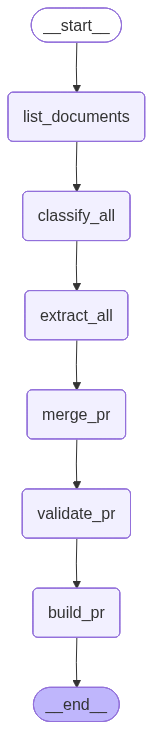


[Section 4] Agent graph (ReAct with tools):

--- Agent Mermaid (saved to output/agent_diagram.mmd) ---

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	agent(agent)
	tools(tools)
	__end__([<p>__end__</p>]):::last
	__start__ --> agent;
	agent -.-> __end__;
	agent -.-> tools;
	tools --> agent;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc


--- Agent ASCII ---

        +-----------+         
        | __start__ |         
        +-----------+         
               *              
               *              
               *              
          +-------+           
          | agent |           
          +-------+.          
          .         .         
        ..           ..       
       .               .      
+---------+         +-------+ 
| __end__ |         | tools | 
+---------+         +-------+ 


C:\Users\mauli\AppData\Local\Temp\ipykernel_28628\1064442622.py:92: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent_graph = create_react_agent(llm, tools=agent_tools)


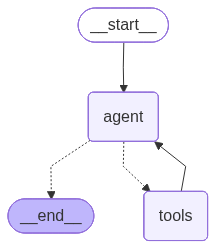

[Section 4] Diagrams done. Pipeline is the production path; agent can be invoked for ad-hoc extraction.


In [8]:
# Draw pipeline diagram (Mermaid, ASCII, PNG)
print("[Section 4] Pipeline diagram (LangGraph):")
try:
    mermaid_str = pipeline_graph.get_graph().draw_mermaid()
    (OUTPUT_DIR / "pipeline_diagram.mmd").parent.mkdir(parents=True, exist_ok=True)
    with open(OUTPUT_DIR / "pipeline_diagram.mmd", "w", encoding="utf-8") as f:
        f.write(mermaid_str)
    print("\n--- Mermaid (saved to output/pipeline_diagram.mmd; paste at mermaid.live for PNG) ---\n")
    print(mermaid_str)
    print("\n--- ASCII ---\n")
    print(pipeline_graph.get_graph().draw_ascii())
    try:
        from IPython.display import Image
        png_bytes = pipeline_graph.get_graph().draw_mermaid_png()
        if png_bytes:
            display(Image(png_bytes))
    except Exception as e:
        print(f"  (PNG render skipped: {e})")
except Exception as e:
    print(f"  Diagram error: {e}")

# Agent with tools: define tools and build ReAct agent graph
from langchain_core.tools import tool
from langgraph.prebuilt import create_react_agent

@tool
def list_documents() -> str:
    """List all documents in the input folder (PDF, Word, Excel). Returns JSON list of {path, filename, size_bytes}."""
    docs = list_uploaded_documents()
    return json.dumps([{"path": d["path"], "filename": d["filename"], "size_bytes": d["size_bytes"]} for d in docs])

@tool
def classify_document_tool(filepath: str, filename: str) -> str:
    """Classify a document by type (PR Form, Quotation, Contract, SOW, etc.). Pass the file path and filename from list_documents."""
    result = classify_document(llm, filepath, filename)
    result["filename"] = filename
    return json.dumps(result)

@tool
def extract_pr_tool(filepath: str, filename: str) -> str:
    """Extract PR header and line items from a PR Form document (Excel/PDF/Word). Returns JSON with header and line_items."""
    try:
        out = parse_pr_with_llm(llm, filepath, filename)
        return json.dumps(out)
    except ValueError as e:
        return json.dumps({"error": str(e)})

@tool
def extract_quote_tool(filepath: str, filename: str) -> str:
    """Extract structured quote data from a Quotation document. Returns JSON with quote_number, quote_date, line_items, etc."""
    try:
        out = parse_quote_with_llm(llm, filepath, filename)
        return json.dumps(out)
    except ValueError as e:
        return json.dumps({"error": str(e)})

@tool
def extract_msa_tool(filepath: str, filename: str) -> str:
    """Extract MSA/contract data from a Contract or Master Service Agreement document. Returns JSON with agreement_id, effective_date, buyer_name, supplier_name."""
    try:
        out = parse_msa_with_llm(llm, filepath, filename)
        return json.dumps(out)
    except ValueError as e:
        return json.dumps({"error": str(e)})

@tool
def merge_pr_tool(parsed_pr_list_json: str) -> str:
    """Merge multiple PR Form extractions into one. Input: JSON array of {header, line_items}. Output: single {header, line_items} with header merged and line_items concatenated."""
    try:
        pr_list = json.loads(parsed_pr_list_json)
        merged = {"header": {}, "line_items": []}
        for p in pr_list:
            h = p.get("header") or {}
            li = p.get("line_items") or []
            merged["header"] = merge_deep(merged["header"], h)
            merged["line_items"] = (merged.get("line_items") or []) + li
        return json.dumps(merged)
    except Exception as e:
        return json.dumps({"error": str(e)})

@tool
def validate_pr_tool(parsed_pr_json: str) -> str:
    """Validate a merged PR JSON against the schema. Returns JSON with valid: bool and errors: list."""
    try:
        data = json.loads(parsed_pr_json)
        valid, errors = validate_parsed_output(data, _pr_schema_parse)
        return json.dumps({"valid": valid, "errors": errors})
    except Exception as e:
        return json.dumps({"valid": False, "errors": [str(e)]})

agent_tools = [list_documents, classify_document_tool, extract_pr_tool, extract_quote_tool, extract_msa_tool, merge_pr_tool, validate_pr_tool]
agent_graph = create_react_agent(llm, tools=agent_tools)

print("\n[Section 4] Agent graph (ReAct with tools):")
try:
    agent_mermaid = agent_graph.get_graph().draw_mermaid()
    with open(OUTPUT_DIR / "agent_diagram.mmd", "w", encoding="utf-8") as f:
        f.write(agent_mermaid)
    print("\n--- Agent Mermaid (saved to output/agent_diagram.mmd) ---\n")
    print(agent_mermaid)
    print("\n--- Agent ASCII ---\n")
    print(agent_graph.get_graph().draw_ascii())
    try:
        from IPython.display import Image
        agent_png = agent_graph.get_graph().draw_mermaid_png()
        if agent_png:
            display(Image(agent_png))
    except Exception as e:
        print(f"  (Agent PNG skipped: {e})")
except Exception as e:
    print(f"  Agent diagram error: {e}")

print("[Section 4] Diagrams done. Pipeline is the production path; agent can be invoked for ad-hoc extraction.")


In [9]:
print("[Section 4] Deriving pr_header, pr_line_items for downstream checks (pr already built in pipeline)...")
# pr was built in pipeline node_build_pr. Rebuild pr_attachments and pr here for notebook consistency; derive pr_header, pr_line_items for Sections 9–10.
pr_header = parsed_pr.get("header", {})
pr_line_items_list = parsed_pr.get("line_items", [])
pr_line_items = {"pr_number": pr_header.get("pr_number", ""), "line_items": pr_line_items_list}
DOC_TYPE_TO_ATTACHMENT_CLASS = {
    "PR Form": "Other",
    "Quotation": "Supplier Quotation",
    "Contract": "Master Service Agreement / Contract Services",
    "Master Service Agreement": "Master Service Agreement / Contract Services",
    "Service Agreement": "Master Service Agreement / Contract Services",
    "SOW": "SOW",
    "Invoice": "Invoice",
    "BidSummary": "Competitive Quote Comparison",
    "Justification": "Technical Evaluation / Business Case",
    "Spec": "Other",
}
parsed_att = parsed_pr.get("attachments") or {}
att_list = (parsed_att.get("attachments") or []) if isinstance(parsed_att, dict) else []
if att_list:
    pr_attachments = {"attachment_count": len(att_list), "attachments": att_list}
else:
    pr_attachments = {
        "attachment_count": len(uploaded),
        "attachments": [
            {
                "attachment_number": i + 1,
                "file_name": u["filename"],
                "file_type": "PDF" if u["filename"].endswith(".pdf") else "Excel" if u["filename"].lower().endswith((".xlsx", ".xls")) else "Word" if u["filename"].lower().endswith((".docx", ".doc")) else "Other",
                "document_classification": DOC_TYPE_TO_ATTACHMENT_CLASS.get(cl.get("document_type"), "Other"),
                "classification_confidence": cl.get("confidence", 0.8),
            }
            for i, (u, cl) in enumerate(zip(uploaded, classified_documents))
        ],
    }
pr = {"header": pr_header, "attachments": pr_attachments, "line_items": pr_line_items_list}
print(f"  -> PR number: {pr_header.get('pr_number') or '(none from parse)'}")
print(f"  -> Line items: {len(pr_line_items_list)}")
print(f"  -> Attachments: {pr_attachments['attachment_count']}")
print("[Section 4] PR built.")

[Section 4] Deriving pr_header, pr_line_items for downstream checks (pr already built in pipeline)...
  -> PR number: PR-2026-007842
  -> Line items: 2
  -> Attachments: 4
[Section 4] PR built.


---
## 5. Save parsed outputs to output folder

**What this does:** Writes parsed data to the **output** folder: **pr.json**, **parsed_quotes.json**, **parsed_msas.json** (filled templates from Section 4). Check result JSONs are written in Section 12.

**Output:** Files under `document_processing_rag/output/`: **pr.json**, **parsed_quotes.json**, **parsed_msas.json**.

In [10]:
print("[Section 5] Saving parsed outputs to output folder...")
# Save parsed outputs right after parsing (before DB, RAG, or checks)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
with open(OUTPUT_DIR / "pr.json", "w", encoding="utf-8") as f:
    json.dump(pr, f, indent=2)
print(f"  -> pr.json ({len(pr.get('line_items', []))} line items, {pr.get('attachments', {}).get('attachment_count', 0)} attachments)")
with open(OUTPUT_DIR / "parsed_quotes.json", "w", encoding="utf-8") as f:
    json.dump(parsed_quotes, f, indent=2)
print(f"  -> parsed_quotes.json ({len(parsed_quotes)} quote(s))")
with open(OUTPUT_DIR / "parsed_msas.json", "w", encoding="utf-8") as f:
    json.dump(parsed_msas, f, indent=2)
print(f"  -> parsed_msas.json ({len(parsed_msas)} MSA(s))")
print(f"[Section 5] Done. Outputs saved to {OUTPUT_DIR}")

[Section 5] Saving parsed outputs to output folder...
  -> pr.json (2 line items, 4 attachments)
  -> parsed_quotes.json (1 quote(s))
  -> parsed_msas.json (1 MSA(s))
[Section 5] Done. Outputs saved to m:\AI_consulting\2025\Bhavin\JSONs\PRtoPOAgent\document_processing_rag\output


---
## 6. Structured data storage (single PR table + structured quote/MSA)

**What this does:** Persists pipeline data in **structured format** (queryable columns) instead of raw JSON blobs. PR data lives in a **single table** `pr` (like the single pr.json): header fields as columns, plus **attachments** and **line_items** stored as JSON columns. Quotes and MSAs use structured columns for scalars and JSON only for arrays (e.g. line_items, scope_categories, signatories).

- **get_engine()** — Returns a SQLAlchemy engine for `DATABASE_URL` (SQLite or PostgreSQL). SQLite file: **BASE_DIR** / `pr_validation.db`.
- **init_db(engine)** — Creates: **pr** (pr_number, pr_status, pr_created_date, total_estimated_value, currency, department, need_by_date, number_of_attachments, buying_channel, contract_reference, category_l1–l4, … + attachments_json, line_items_json); **parsed_quote** (source_file, quote_number, quote_date, valid_through, currency, supplier_name, total, subtotal, payment_terms, contract_ref, line_items_json, …); **parsed_msa** (source_file, agreement_id, effective_date, end_date, buyer_name, supplier_name, payment_terms_standard, maximum_contract_value, scope_categories_json, signatories_json, …).
- Inserts current **pr** (from `pr` dict), **parsed_quotes**, and **parsed_msas** into these tables. Parsed outputs were already saved to **output/** in Section 5.

**Output:** Database populated with structured rows. View in [DBeaver](https://dbeaver.io/) (SQLite or PostgreSQL).

In [11]:
print("[Section 6] Setting up structured DB (pr, parsed_quote, parsed_msa tables)...")
try:
    from sqlalchemy import create_engine, text
    from sqlalchemy.engine import Engine
except ImportError:
    create_engine = None
    print("  -> Install sqlalchemy for DB persistence: pip install sqlalchemy")

USE_POSTGRES = DATABASE_URL.strip().lower().startswith("postgresql")

def get_engine() -> Engine:
    url = DATABASE_URL
    if url.startswith("sqlite") and ("pr_validation" in url or url == "sqlite:///pr_validation.db"):
        url = "sqlite:///" + str(BASE_DIR / "pr_validation.db")
    return create_engine(url, echo=False)

# Single PR table: header columns + attachments_json, line_items_json (structured except nested arrays)
PR_HEADER_COLS = "pr_number TEXT UNIQUE, pr_status TEXT, pr_created_date TEXT, total_estimated_value REAL, currency TEXT, department TEXT, need_by_date TEXT, number_of_attachments INTEGER, buying_channel TEXT, contract_reference TEXT, category_l1 TEXT, category_l2 TEXT, category_l3 TEXT, category_l4 TEXT, requestor_name TEXT, company_name TEXT, attachments_json TEXT, line_items_json TEXT"
QUOTE_COLS = "source_file TEXT, quote_number TEXT, quote_date TEXT, valid_through TEXT, currency TEXT, supplier_name TEXT, total REAL, subtotal REAL, payment_terms TEXT, contract_ref TEXT, line_items_json TEXT"
MSA_COLS = "source_file TEXT, agreement_id TEXT, effective_date TEXT, end_date TEXT, buyer_name TEXT, supplier_name TEXT, payment_terms_standard TEXT, maximum_contract_value REAL, scope_categories_json TEXT, signatories_json TEXT"

def init_db(engine):
    if USE_POSTGRES:
        with engine.connect() as conn:
            conn.execute(text(f"""CREATE TABLE IF NOT EXISTS pr (id SERIAL PRIMARY KEY, {PR_HEADER_COLS}, created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP)"""))
            conn.execute(text(f"""CREATE TABLE IF NOT EXISTS parsed_quote (id SERIAL PRIMARY KEY, {QUOTE_COLS}, created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP)"""))
            conn.execute(text(f"""CREATE TABLE IF NOT EXISTS parsed_msa (id SERIAL PRIMARY KEY, {MSA_COLS}, created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP)"""))
            conn.commit()
    else:
        with engine.connect() as conn:
            conn.execute(text(f"""CREATE TABLE IF NOT EXISTS pr (id INTEGER PRIMARY KEY AUTOINCREMENT, {PR_HEADER_COLS}, created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP)"""))
            conn.execute(text(f"""CREATE TABLE IF NOT EXISTS parsed_quote (id INTEGER PRIMARY KEY AUTOINCREMENT, {QUOTE_COLS}, created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP)"""))
            conn.execute(text(f"""CREATE TABLE IF NOT EXISTS parsed_msa (id INTEGER PRIMARY KEY AUTOINCREMENT, {MSA_COLS}, created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP)"""))
            conn.commit()

def row_from_pr(pr_dict):
    h = pr_dict.get("header", {})
    return {
        "pr_number": h.get("pr_number"),
        "pr_status": h.get("pr_status"),
        "pr_created_date": h.get("pr_created_date"),
        "total_estimated_value": h.get("total_estimated_value"),
        "currency": h.get("currency"),
        "department": h.get("department"),
        "need_by_date": h.get("need_by_date"),
        "number_of_attachments": h.get("number_of_attachments"),
        "buying_channel": h.get("buying_channel"),
        "contract_reference": h.get("contract_reference"),
        "category_l1": h.get("category_l1"),
        "category_l2": h.get("category_l2"),
        "category_l3": h.get("category_l3"),
        "category_l4": h.get("category_l4"),
        "requestor_name": h.get("requestor_name"),
        "company_name": h.get("company_name"),
        "attachments_json": json.dumps(pr_dict.get("attachments", {})),
        "line_items_json": json.dumps(pr_dict.get("line_items", [])),
    }

def row_from_quote(q):
    return {
        "source_file": q.get("source_file_name", ""),
        "quote_number": q.get("quote_number"),
        "quote_date": q.get("quote_date"),
        "valid_through": q.get("valid_through"),
        "currency": q.get("currency"),
        "supplier_name": q.get("supplier_name"),
        "total": q.get("total"),
        "subtotal": q.get("subtotal"),
        "payment_terms": q.get("payment_terms"),
        "contract_ref": q.get("contract_ref"),
        "line_items_json": json.dumps(q.get("line_items", [])),
    }

def row_from_msa(m):
    return {
        "source_file": m.get("source_file_name", ""),
        "agreement_id": m.get("agreement_id"),
        "effective_date": m.get("effective_date"),
        "end_date": m.get("end_date"),
        "buyer_name": m.get("buyer_name"),
        "supplier_name": m.get("supplier_name"),
        "payment_terms_standard": m.get("payment_terms_standard"),
        "maximum_contract_value": m.get("maximum_contract_value"),
        "scope_categories_json": json.dumps(m.get("scope_categories") or []),
        "signatories_json": json.dumps(m.get("signatories") or []),
    }

if create_engine:
    engine = get_engine()
    init_db(engine)
    pr_row = row_from_pr(pr)
    with engine.connect() as conn:
        if USE_POSTGRES:
            conn.execute(text("""INSERT INTO pr (pr_number, pr_status, pr_created_date, total_estimated_value, currency, department, need_by_date, number_of_attachments, buying_channel, contract_reference, category_l1, category_l2, category_l3, category_l4, requestor_name, company_name, attachments_json, line_items_json)
                VALUES (:pr_number, :pr_status, :pr_created_date, :total_estimated_value, :currency, :department, :need_by_date, :number_of_attachments, :buying_channel, :contract_reference, :category_l1, :category_l2, :category_l3, :category_l4, :requestor_name, :company_name, :attachments_json, :line_items_json)
                ON CONFLICT (pr_number) DO UPDATE SET pr_status=EXCLUDED.pr_status, total_estimated_value=EXCLUDED.total_estimated_value, attachments_json=EXCLUDED.attachments_json, line_items_json=EXCLUDED.line_items_json"""), pr_row)
        else:
            conn.execute(text("DELETE FROM pr WHERE pr_number = :pn"), {"pn": pr_row["pr_number"]})
            conn.execute(text("""INSERT INTO pr (pr_number, pr_status, pr_created_date, total_estimated_value, currency, department, need_by_date, number_of_attachments, buying_channel, contract_reference, category_l1, category_l2, category_l3, category_l4, requestor_name, company_name, attachments_json, line_items_json)
                VALUES (:pr_number, :pr_status, :pr_created_date, :total_estimated_value, :currency, :department, :need_by_date, :number_of_attachments, :buying_channel, :contract_reference, :category_l1, :category_l2, :category_l3, :category_l4, :requestor_name, :company_name, :attachments_json, :line_items_json)"""), pr_row)
        for q in parsed_quotes:
            conn.execute(text("""INSERT INTO parsed_quote (source_file, quote_number, quote_date, valid_through, currency, supplier_name, total, subtotal, payment_terms, contract_ref, line_items_json)
                VALUES (:source_file, :quote_number, :quote_date, :valid_through, :currency, :supplier_name, :total, :subtotal, :payment_terms, :contract_ref, :line_items_json)"""), row_from_quote(q))
        for m in parsed_msas:
            conn.execute(text("""INSERT INTO parsed_msa (source_file, agreement_id, effective_date, end_date, buyer_name, supplier_name, payment_terms_standard, maximum_contract_value, scope_categories_json, signatories_json)
                VALUES (:source_file, :agreement_id, :effective_date, :end_date, :buyer_name, :supplier_name, :payment_terms_standard, :maximum_contract_value, :scope_categories_json, :signatories_json)"""), row_from_msa(m))
        conn.commit()
    print("  -> pr, parsed_quote, parsed_msa tables written (structured).", "(PostgreSQL)" if USE_POSTGRES else "(SQLite)")
    print("[Section 6] Done.")

[Section 6] Setting up structured DB (pr, parsed_quote, parsed_msa tables)...
  -> pr, parsed_quote, parsed_msa tables written (structured). (SQLite)
[Section 6] Done.


**Check system prompts and result template (scalable pattern)**

Every compliance check uses: (1) a **system prompt** that describes the check’s purpose and policy rules, and (2) the check result **template** (the `example` from `check_0X_result.json`) so the LLM returns JSON that matches the schema. This lets you add more checks later by adding a new result schema and a new system prompt.

- **build_check_system_prompt(check_schema)** — Builds a system prompt from the schema’s `description` and `example` (output structure).
- **CHECK_1_SYSTEM** / **CHECK_2_SYSTEM** — Built from **check1_schema** and **check2_schema**; used by **run_check_with_llm**.
- **run_check_with_llm(llm, check_num, context_dict)** — Sends system prompt + context to the LLM; parses JSON; validates required keys and status enum; on failure, **one retry** with validation errors in the user message; returns result dict or `None` (then use deterministic fallback).

**Schema locations:** The result **template** is the **example** from `schemas/compliance_checks/check_01_attachment_existence_classification/check_01_result.json` and `check_02_document_validity_applicability/check_02_result.json`. To add Check 3+: add a folder `check_0N_.../check_0N_result.json` with **example**, extend **load_check_result(N)** if needed, then call **run_check_with_llm(llm, N, context)**.

---
## 7. RAG and vector storage

**What you need to do (configuration)**

| Goal | Option A — AWS | Option B — No AWS (local / free) |
|------|----------------|-----------------------------------|
| **Embeddings** | Set **AWS_REGION** (or **AWS_PROFILE**) and **BEDROCK_MODEL_ID** (Section 0). Notebook uses **Titan** via Bedrock. | Install **sentence-transformers** (`pip install sentence-transformers`). Notebook uses **all-MiniLM-L6-v2**. If not installed, a **stub** (zeros) is used so the notebook still runs. |
| **Vector storage** | Set **OPENSEARCH_ENDPOINT** (or **OPENSEARCH_HOST**) so the notebook indexes and searches **AWS OpenSearch**. Requires **opensearch-py** and IAM/OpenSearch access. | Leave unset → notebook uses **in-memory** store (list of chunks + embeddings). No extra setup. |
| **Vector storage** | **AWS OpenSearch** (required when ENV_MODE=aws). Index created/used automatically. | **Qdrant Cloud** (required when ENV_MODE=local). Collection created/used automatically. |

**What runs automatically (no config)**

- **Chunking:** Text from uploaded files and parsed PR/quote/MSA summaries is split into chunks (500 chars, 50 overlap) via **RecursiveCharacterTextSplitter** (LangChain) or a simple splitter.
- **Corpus:** Chunks from each uploaded file + one chunk per parsed PR header, quote, and MSA.
- **Indexing:** Chunks are embedded and stored in OpenSearch (AWS) or Qdrant (local). **rag_search(query, k=3)** returns top-k chunks; used by the orchestrator in Section 8.

In [12]:
print("[Section 7] Setting up RAG (embeddings + vector store)...")
# RAG: embeddings + vector store (OpenSearch for AWS, Qdrant for local)
VECTOR_INDEX_NAME = os.environ.get("OPENSEARCH_INDEX_NAME", "pr2po-rag")
QDRANT_COLLECTION = os.environ.get("QDRANT_COLLECTION_NAME", "pr2po")
TITAN_DIM = 1536
SENTENCE_TRANSFORMERS_DIM = 384

def get_embedding_model():
    """Return (embed_fn, dimension). AWS: Titan (1536). Local: sentence-transformers (384)."""
    if USE_TITAN:
        from langchain_aws import BedrockEmbeddings
        be = BedrockEmbeddings(region_name=os.environ.get("AWS_REGION", "us-east-1"))
        def embed(texts):
            if isinstance(texts, str):
                texts = [texts]
            return be.embed_documents(texts)
        return embed, TITAN_DIM
    from sentence_transformers import SentenceTransformer
    model = SentenceTransformer("all-MiniLM-L6-v2")
    def embed(texts):
        if isinstance(texts, str):
            texts = [texts]
        return model.encode(texts).tolist()
    return embed, SENTENCE_TRANSFORMERS_DIM

def chunk_text(text: str, chunk_size: int = 500, overlap: int = 50) -> list[str]:
    if not text or not text.strip():
        return []
    try:
        from langchain_text_splitters import RecursiveCharacterTextSplitter
        splitter = RecursiveCharacterTextSplitter(chunk_size=chunk_size, chunk_overlap=overlap)
        return splitter.split_text(text)
    except ImportError:
        return [text[i : i + chunk_size] for i in range(0, len(text), chunk_size - overlap)]

# Build corpus
rag_chunks = []
for u in uploaded:
    t = extract_text_from_file(u["path"], max_chars=4000)
    for c in chunk_text(t):
        if c.strip():
            rag_chunks.append({"source": u["filename"], "text": c.strip()})
rag_chunks.append({"source": "pr", "text": json.dumps(pr.get("header", {}), indent=0)[:1500]})
for q in parsed_quotes:
    rag_chunks.append({"source": "quote", "text": json.dumps({k: v for k, v in q.items() if k != "line_items"}, indent=0)[:1500]})
for m in parsed_msas:
    rag_chunks.append({"source": "msa", "text": json.dumps({k: v for k, v in m.items() if k not in ("scope_categories", "signatories")}, indent=0)[:1500]})

embed_fn, VECTOR_DIM = get_embedding_model()
texts_for_embed = [c["text"] for c in rag_chunks]
rag_embeddings = embed_fn(texts_for_embed) if texts_for_embed else []

qdrant_client = None
opensearch_client = None

if USE_QDRANT:
    from qdrant_client import QdrantClient
    from qdrant_client.models import VectorParams, Distance, PointStruct
    qdrant_url = (os.environ.get("QDRANT_URL") or "").strip().rstrip("/")
    if ":6333" not in qdrant_url:
        qdrant_url = qdrant_url + ":6333"
    qdrant_client = QdrantClient(url=qdrant_url, api_key=os.environ.get("QDRANT_API_KEY"))
    if not qdrant_client.collection_exists(QDRANT_COLLECTION):
        qdrant_client.create_collection(collection_name=QDRANT_COLLECTION, vectors_config=VectorParams(size=VECTOR_DIM, distance=Distance.COSINE))
    points = [PointStruct(id=i, vector=rag_embeddings[i], payload={"text": rag_chunks[i]["text"], "source": rag_chunks[i]["source"]}) for i in range(len(rag_chunks))]
    qdrant_client.upsert(collection_name=QDRANT_COLLECTION, points=points)
    print("RAG: Qdrant collection", QDRANT_COLLECTION, "—", len(rag_chunks), "chunks indexed.")

if USE_OPENSEARCH:
    from opensearchpy import OpenSearch
    from urllib.parse import urlparse
    _os_url = (os.environ.get("OPENSEARCH_ENDPOINT") or os.environ.get("OPENSEARCH_HOST") or "").strip()
    _parsed = urlparse(_os_url if _os_url.startswith("http") else "https://" + _os_url)
    _host = _parsed.hostname or _os_url.split("/")[0]
    _port = _parsed.port or (443 if _parsed.scheme == "https" else 9200)
    _use_ssl = _parsed.scheme == "https"
    _auth = (os.environ.get("OPENSEARCH_USER"), os.environ.get("OPENSEARCH_PASSWORD")) if os.environ.get("OPENSEARCH_USER") else None
    opensearch_client = OpenSearch(hosts=[{"host": _host, "port": _port, "use_ssl": _use_ssl}], http_auth=_auth)
    if not opensearch_client.indices.exists(index=VECTOR_INDEX_NAME):
        opensearch_client.indices.create(index=VECTOR_INDEX_NAME, body={"settings": {"index.knn": True}, "mappings": {"properties": {"embedding": {"type": "knn_vector", "dimension": VECTOR_DIM, "method": {"name": "hnsw", "space_type": "cosinesimil"}}, "text": {"type": "keyword"}, "source": {"type": "keyword"}}}})
    for i, (chunk, emb) in enumerate(zip(rag_chunks, rag_embeddings)):
        opensearch_client.index(index=VECTOR_INDEX_NAME, id=i, body={"text": chunk["text"], "source": chunk["source"], "embedding": emb})
    opensearch_client.indices.refresh(index=VECTOR_INDEX_NAME)
    print("RAG: OpenSearch index", VECTOR_INDEX_NAME, "—", len(rag_chunks), "chunks indexed.")

def rag_search(query: str, k: int = 3):
    """Semantic search. Returns list of {text, source, score}."""
    q_vec = embed_fn([query])
    if not q_vec:
        return []
    q_vec = q_vec[0]
    if USE_QDRANT and qdrant_client:
        response = qdrant_client.query_points(collection_name=QDRANT_COLLECTION, query=q_vec, limit=k)
        points = getattr(response, "points", []) or []
        return [{"text": (getattr(p, "payload", None) or {}).get("text", ""), "source": (getattr(p, "payload", None) or {}).get("source", ""), "score": getattr(p, "score", None) or 0.0} for p in points]
    if USE_OPENSEARCH and opensearch_client:
        body = {"size": k, "query": {"knn": {"embedding": {"vector": q_vec, "k": k}}}}
        res = opensearch_client.search(index=VECTOR_INDEX_NAME, body=body)
        hits = res.get("hits", {}).get("hits", [])
        return [{"text": h.get("_source", {}).get("text", ""), "source": h.get("_source", {}).get("source", ""), "score": float(h.get("_score", 0))} for h in hits]
    return []

vector_store = [{"chunk": c, "embedding": e} for c, e in zip(rag_chunks, rag_embeddings)]
print("  -> Embeddings:", "AWS Titan (Bedrock)" if USE_TITAN else "sentence-transformers (all-MiniLM-L6-v2)")
print("  -> Vector storage:", "AWS OpenSearch" if USE_OPENSEARCH else "Qdrant Cloud")
print("  ->", len(vector_store), "chunks ready.")
print("[Section 7] Done.")

[Section 7] Setting up RAG (embeddings + vector store)...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


RAG: Qdrant collection pr2po — 32 chunks indexed.
  -> Embeddings: sentence-transformers (all-MiniLM-L6-v2)
  -> Vector storage: Qdrant Cloud
  -> 32 chunks ready.
[Section 7] Done.


---
## 8. Agentic orchestrator (SQL + RAG)

**What this does:** An **orchestrator** agent that can answer questions by combining **structured SQL** (pr, parsed_quote, parsed_msa tables) and **unstructured RAG** (vector search over document chunks). You ask a test question; the agent decides whether to query the database, search the vector store, or both, and returns an answer.

- **Tools:** (1) **query_sql** — run a read-only SQL query on the current engine (pr, parsed_quote, parsed_msa). (2) **rag_search** — semantic search using `rag_search(query, k=3)` from Section 7.
- **Agent loop:** Given a user question, the agent (or a simple dispatcher) calls the appropriate tool(s) and formats a reply. For demo we run one **test question** (e.g. "What is the PR number and total value?" or "Which contract applies to this PR?") and print the answer.

**Output:** Answer to the test question, using structured data and/or RAG results. After this section we proceed to **Check 1** and **Check 2** (Sections 9–10).

In [13]:
print("[Section 8] Setting up orchestrator (SQL + RAG tools)...")
# Orchestrator tools: structured SQL + RAG
def query_sql(sql: str, engine=None):
    """Run read-only SQL on pr_validation DB. Returns list of dicts (rows)."""
    eng = engine or (get_engine() if create_engine else None)
    if not eng:
        return [{"error": "No database engine"}]
    try:
        with eng.connect() as conn:
            result = conn.execute(text(sql))
            rows = result.fetchall()
            keys = result.keys() if hasattr(result, "keys") else list(rows[0].keys()) if rows else []
            return [dict(zip(keys, r)) for r in rows]
    except Exception as e:
        return [{"error": str(e)}]

def orchestrator_answer(question: str, engine=None) -> str:
    """Answer a question using SQL and/or RAG. Simple strategy: try SQL for factual PR/quote/MSA, add RAG for context."""
    parts = []
    # 1) Try to get PR / quote / MSA facts from SQL
    if create_engine and (engine or get_engine()):
        eng = engine or get_engine()
        for q in ["SELECT pr_number, total_estimated_value, currency, department FROM pr LIMIT 1",
                  "SELECT quote_number, supplier_name, total, quote_date FROM parsed_quote LIMIT 1",
                  "SELECT agreement_id, supplier_name, effective_date, end_date FROM parsed_msa LIMIT 1"]:
            try:
                rows = query_sql(q, eng)
                if rows and "error" not in str(rows[0]):
                    parts.append("Structured data: " + json.dumps(rows))
            except Exception:
                pass
    # 2) RAG search for semantic context
    rag_results = rag_search(question, k=3)
    if rag_results:
        parts.append("Relevant passages: " + " | ".join(r["text"][:200] + "..." for r in rag_results))
    # 3) Optional: ask LLM to synthesize (or just return combined)
    if not parts:
        return "No structured data or RAG results available."
    context = "\n\n".join(parts)
    if len(context) > 3000:
        context = context[:3000] + "..."
    prompt = f"Context:\n{context}\n\nQuestion: {question}\n\nAnswer concisely based on the context above."
    try:
        out = llm.invoke([HumanMessage(content=prompt)])
        return out.content if hasattr(out, "content") else str(out)
    except Exception as e:
        return f"Context found but LLM failed: {e}\n\nRaw context:\n{context[:1500]}"

# Test question
TEST_QUESTION = "What is the PR number and total value? Which contract and quote apply?"
answer = orchestrator_answer(TEST_QUESTION)
print("  -> Test question:", TEST_QUESTION)
print("  -> Orchestrator answer:", answer)
print("[Section 8] Done.")

[Section 8] Setting up orchestrator (SQL + RAG tools)...
  -> Test question: What is the PR number and total value? Which contract and quote apply?
  -> Orchestrator answer: Based on the provided context, the PR number and total value are:

- PR number: PR-2026-007842
- Total value: $71,250

The contract that applies is:

- MSA-CDW-2024-0156 (valid through 12/31/2026)

The quote that applies is:

- Q25-0847-MTECH (from CDW Corporation, dated 2026-01-13)
[Section 8] Done.


---
## Setup for compliance checks (used by Sections 9–10)

**Transition:** Extraction, RAG, and the orchestrator (Sections 4–8) are done. Next we run **compliance checks** on the parsed PR, quotes, and MSAs to validate attachment policy, document dates, and applicability.

**What the cell below does:**

- **`build_check_system_prompt(check_schema, policy_rules_text)`** — Builds the LLM system prompt for a compliance check from the schema’s `description` and `example` (the expected JSON output template). Each check has a result schema (e.g. `check_01_result.json`, `check_02_result.json`); this function turns that into the exact instructions the model sees so it outputs valid JSON with the right keys and status values (**PASS**, **FAIL**, **NEEDS_REVIEW**).
- **Check 1 & 2 policies and prompts** — `CHECK_1_SYSTEM` and `CHECK_2_SYSTEM` are the system prompts for **Check 1** (attachment existence & classification) and **Check 2** (document validity & applicability). Policy text is merged into the prompt so the model knows the rules.
- **`get_check_validation_errors`** / **`validate_check_output`** — Validate the LLM’s JSON against the check schema (used for one retry with error feedback).
- **`run_check_with_llm`** — Runs a single check: sends system prompt + context (PR, quotes, MSAs) to the LLM, parses JSON, validates, and retries once if validation fails.

Sections **9** and **10** use these to run Check 1 and Check 2.

In [14]:
# Build check system prompts from schema (description + example template). Reuse for any future check.
def build_check_system_prompt(check_schema: dict, policy_rules_text: str = "") -> str:
    """Build system prompt for a compliance check. Uses schema description and example as output template."""
    desc = check_schema.get("description", "Compliance check. Output valid JSON only.")
    example = check_schema.get("example", {})
    example_json = json.dumps(example, indent=2)[:4000]
    prompt = f"""You are a procurement compliance checker. {desc}

Output MUST be valid JSON matching this structure (adapt values to the context provided by the user). No markdown, no code fence.

Example output structure:
{example_json}

Rules: Output only the JSON object. Use exactly the keys shown. Status values: PASS, FAIL, or NEEDS_REVIEW."""
    if policy_rules_text:
        prompt += "\n\nPolicy rules to apply:\n" + policy_rules_text
    return prompt

# Check 1: Attachment Existence & Classification — policy rules and template from check_01_result.json
CHECK_1_POLICY = """- PR must have at least one attachment. Value >= 5000 requires at least 1 quote or contract; value >= 50000 may require 3 quotes or one contract (contract can substitute). Valid document types: Quotation, Contract, SOW, Service Agreement. Invoice on PR is a red flag (after-the-fact). Confidence < 0.8 on any classification → NEEDS_REVIEW."""
CHECK_1_SYSTEM = build_check_system_prompt(check1_schema, CHECK_1_POLICY)

# Check 2: Document Validity & Applicability — template from check_02_result.json
CHECK_2_POLICY = """- Check 2 is dates and timings only. Quote date must be <= PR date. Quote valid_through must be >= PR date. Contract effective <= PR date, contract not expired >= PR date. Flag near-expiry or if contract does not cover delivery period. PASS = all date/timing rules pass; FAIL = expired or wrong sequence; NEEDS_REVIEW = e.g. expiration within 30 days. No supplier/currency/total here (other checks)."""
CHECK_2_SYSTEM = build_check_system_prompt(check2_schema, CHECK_2_POLICY)

def get_check_validation_errors(parsed: dict, check_schema: dict) -> list[str]:
    """Return list of validation errors (missing required, invalid status). Used for retry prompt."""
    errors = []
    if not parsed or not isinstance(parsed, dict):
        return ["No valid JSON object returned"]
    required = check_schema.get("required", [])
    for r in required:
        if r not in parsed or parsed[r] is None:
            errors.append(f"Missing required: {r}")
    status_key = "check_1_status" if "check_1_status" in required else "check_2_status"
    if status_key in required and status_key in parsed:
        if parsed[status_key] not in ("PASS", "FAIL", "NEEDS_REVIEW"):
            errors.append(f"Invalid {status_key}: must be PASS, FAIL, or NEEDS_REVIEW")
    return errors

def validate_check_output(parsed: dict, check_schema: dict) -> bool:
    """Ensure parsed result has required keys for this check. Used after LLM response."""
    return len(get_check_validation_errors(parsed, check_schema)) == 0

def run_check_with_llm(llm, check_num: int, context_dict: dict, max_context_chars: int = 8000) -> dict | None:
    """Run a compliance check using LLM + system prompt + result template. One retry with validation errors. Returns result dict or None (use deterministic fallback)."""
    if check_num == 1:
        schema = check1_schema
        system_prompt = CHECK_1_SYSTEM
    elif check_num == 2:
        schema = check2_schema
        system_prompt = CHECK_2_SYSTEM
    else:
        schema = load_check_result(check_num)
        system_prompt = build_check_system_prompt(schema)
    context_str = json.dumps(context_dict, indent=2)
    if len(context_str) > max_context_chars:
        context_str = context_str[:max_context_chars] + "\n... (truncated)"
    user_msg = f"Context for this compliance check:\n{context_str}\n\nProduce the check result JSON matching the required structure. Output only valid JSON."
    msg = [SystemMessage(content=system_prompt), HumanMessage(content=user_msg)]
    out = llm.invoke(msg)
    text_out = out.content if hasattr(out, "content") else str(out)
    parsed = _parse_json_from_llm(text_out)
    if parsed and validate_check_output(parsed, schema):
        return parsed
    # One retry with validation errors
    errors = get_check_validation_errors(parsed, schema) if parsed else ["Failed to parse JSON"]
    retry_msg = f"Context:\n{context_str}\n\nPrevious attempt had errors: {errors}\nReturn complete valid JSON that fixes these. Output only JSON."
    retry_out = llm.invoke([SystemMessage(content=system_prompt), HumanMessage(content=retry_msg)])
    retry_text = retry_out.content if hasattr(retry_out, "content") else str(retry_out)
    retry_parsed = _parse_json_from_llm(retry_text)
    if retry_parsed and validate_check_output(retry_parsed, schema):
        return retry_parsed
    return None

---
## 9. PR Validation — Check 1: Attachment Existence & Classification

**What this does:** Evaluates whether the PR has the **right attachments** for its value band.

- **Thresholds:** `THRESHOLD_QUOTE_ABOVE` (e.g. 5000) → at least one quote or contract required; `THRESHOLD_COMPETITIVE` (e.g. 50000) → 3 quotes or one contract. **CONTRACT_SATISFIES_QUOTES** allows a contract to substitute for multiple quotes.
- **Primary:** **run_check_with_llm(llm, 1, context_check1)** uses **CHECK_1_SYSTEM** (system prompt with policy rules + result template from **check_01_result.json**). Context = pr_header, classified_documents, policy_rules. LLM returns full check result JSON; validated with **validate_check_output**.
- **Fallback:** **run_check_1(pr_header, classified_documents)** — deterministic logic if LLM parse/validation fails.
- **Status:** PASS / FAIL / NEEDS_REVIEW per policy.

**Output:** **check1_result** — structure matches **check_01_result.json**. Same pattern scales to more checks (add schema + system prompt, call **run_check_with_llm**).

In [15]:
print("[Section 9] Running Check 1: Attachment Existence & Classification...")
# Threshold policy (from config / RDS in production)
THRESHOLD_QUOTE_ABOVE = 5000      # value above which at least 1 quote required
THRESHOLD_COMPETITIVE = 50000    # value above which 3 quotes or contract
CONTRACT_SATISFIES_QUOTES = True # valid contract can substitute for 3 quotes

def run_check_1(pr_header: dict, classified_documents: list) -> dict:
    total = float(pr_header.get("total_estimated_value", 0))
    n_attachments = len(classified_documents)
    valid_types = {"Quotation", "Contract", "SOW", "Service Agreement"}
    valid_support = sum(1 for c in classified_documents if c.get("document_type") in valid_types)
    invoice_detected = any(c.get("document_type") == "Invoice" for c in classified_documents)
    missing = []
    if total >= THRESHOLD_QUOTE_ABOVE and valid_support < 1:
        missing.append("Requires at least 1 quote or contract, none found")
    if total >= THRESHOLD_COMPETITIVE and valid_support < 2 and not CONTRACT_SATISFIES_QUOTES:
        missing.append("Requires 3 quotes or active contract for value > 50K")
    policy_met = len(missing) == 0 and n_attachments >= 1
    low_confidence = any(c.get("confidence", 1) < 0.8 for c in classified_documents)
    status = "FAIL" if not policy_met else ("NEEDS_REVIEW" if low_confidence or invoice_detected else "PASS")
    return {
        "check_id": "check_01",
        "check_name": "Attachment Existence & Classification",
        "check_1_status": status,
        "attachments_found": n_attachments,
        "classified_documents": classified_documents,
        "valid_support_docs_found": valid_support,
        "policy_requirements_met": policy_met,
        "missing_requirements": missing,
        "invoice_detected": invoice_detected,
        "sub_checks": [
            {"name": "At least one attachment exists on PR", "passed": n_attachments >= 1},
            {"name": "Agent classified attachment as Quote/SOW/Contract", "passed": valid_support >= 1},
            {"name": "Required documents for value tier present", "passed": policy_met},
        ],
        "field_level_assessment": [
            {"field_name": "Attachment Count", "status": "pass" if n_attachments >= 1 else "fail", "confidence": 1.0, "detail": f"{n_attachments} documents attached"},
            {"field_name": "Quote Document Type", "status": "pass" if valid_support else "fail", "confidence": classified_documents[0].get("confidence", 0.9) if classified_documents else 0, "detail": f"Classified: {[c.get('document_type') for c in classified_documents]}"},
        ],
        "evidence": [
            {"field": "Attachments Found", "extracted_value": f"{n_attachments} documents", "pr_value": "Required: ≥1", "match": "Match" if n_attachments >= 1 else "Mismatch"},
            {"field": "Document Types", "extracted_value": ", ".join(f"{c.get('document_type')} ({c.get('confidence', 0):.0%})" for c in classified_documents), "pr_value": "Expected: Quote or Contract", "match": "Match" if valid_support else "Mismatch"},
        ],
        "policy_reference": "Procurement Policy v3.2, Section 3.1",
    }

# Run Check 1 via LLM (system prompt + template from check_01_result.json); fallback to deterministic
context_check1 = {
    "pr_header": pr_header,
    "classified_documents": classified_documents,
    "policy_rules": {"THRESHOLD_QUOTE_ABOVE": THRESHOLD_QUOTE_ABOVE, "THRESHOLD_COMPETITIVE": THRESHOLD_COMPETITIVE, "CONTRACT_SATISFIES_QUOTES": CONTRACT_SATISFIES_QUOTES},
}
check1_result = run_check_with_llm(llm, 1, context_check1)
if check1_result is None:
    check1_result = run_check_1(pr_header, classified_documents)
    print("  -> Used deterministic fallback (LLM parse/validation failed).")
else:
    print("  -> Result from LLM (system prompt + template).")
print(f"  -> Check 1 status: {check1_result['check_1_status']}")
print(f"  -> Policy requirements met: {check1_result['policy_requirements_met']}")
print("  -> Missing:", check1_result.get("missing_requirements", []))
print("[Section 9] Done.")

[Section 9] Running Check 1: Attachment Existence & Classification...
  -> Result from LLM (system prompt + template).
  -> Check 1 status: PASS
  -> Policy requirements met: True
  -> Missing: []
[Section 9] Done.


---
## 10. PR Validation — Check 2: Document Validity & Applicability

**What this does:** Checks that the **parsed quote** (and context) is valid and applicable to the PR.

- **Primary:** **run_check_with_llm(llm, 2, context_check2)** uses **CHECK_2_SYSTEM** (system prompt + result template from **check_02_result.json**). Context = pr_header, pr_line_items, parsed_quotes, parsed_msas. LLM returns full check result JSON.
- **Fallback:** **run_check_2(...)** — deterministic logic when no parsed quote or LLM fails. **parse_date(s)** used in fallback for date comparison.
- **Status:** PASS / FAIL / NEEDS_REVIEW. If no **parsed_quotes**, use deterministic only.

**Output:** **check2_result** — structure matches **check_02_result.json**. To add Check 3+ later: add **check_0N_result.json** (with `example`) and call **run_check_with_llm(llm, N, context)**.

In [16]:
print("[Section 10] Running Check 2: Document Validity & Applicability...")
from datetime import datetime

def parse_date(s) -> datetime | None:
    if not s:
        return None
    for fmt in ("%Y-%m-%d", "%Y/%m/%d", "%m/%d/%Y", "%d-%b-%Y", "%b %d, %Y"):
        try:
            return datetime.strptime(str(s).strip()[:10], fmt)
        except ValueError:
            continue
    return None

def run_check_2(pr_header: dict, pr_line_items: dict, parsed_quotes: list, parsed_msas: list) -> dict:
    """Check 2: dates and timings only (quote/contract dates)."""
    pr_date_s = pr_header.get("pr_created_date", "")
    pr_date = parse_date(pr_date_s)
    pr_need_by = parse_date(pr_header.get("need_by_date", ""))
    quote_date_ok = quote_expiry_ok = True
    quote_staleness = False
    contract_effective_ok = contract_not_expired_ok = True
    covers_delivery_warning = near_expiry_warning = False
    evidence_list = []

    if not parsed_quotes:
        return {
            "check_id": "check_02",
            "check_name": "Document Validity — Dates & Timings",
            "check_2_status": "NEEDS_REVIEW",
            "summary_description": "No quote parsed; cannot validate dates.",
            "quotation_validity": {"quote_date_sequence_pass": None, "quote_not_expired_pass": None, "quote_staleness_warning": False},
            "contract_validity": {"contract_effective_pass": None, "contract_not_expired_pass": None, "covers_delivery_period_warning": False, "near_expiry_warning": False},
            "sub_checks": [],
            "field_level_assessment": [],
            "evidence": [],
            "policy_reference": "Procurement Policy v3.2, Section 3.2 (dates & timings).",
        }

    q = parsed_quotes[0]
    quote_date = parse_date(q.get("quote_date"))
    valid_through = parse_date(q.get("valid_through"))
    if pr_date and quote_date:
        quote_date_ok = quote_date <= pr_date
        evidence_list.append({"field": "Quote Date", "extracted_value": q.get("quote_date", ""), "pr_value": f"PR Date: {pr_date_s}", "match": "Match" if quote_date_ok else "Mismatch"})
    if pr_date and valid_through:
        quote_expiry_ok = valid_through >= pr_date
        days_left = (valid_through - pr_date).days if pr_date and valid_through else 0
        quote_staleness = days_left < 30 if days_left is not None else False
        evidence_list.append({"field": "Quote Expiration", "extracted_value": q.get("valid_through", ""), "pr_value": f"Required: >= {pr_date_s}", "match": "Match" if quote_expiry_ok else "Mismatch"})

    if parsed_msas:
        m = parsed_msas[0]
        eff = parse_date(m.get("effective_date"))
        end = parse_date(m.get("end_date"))
        if pr_date and eff:
            contract_effective_ok = eff <= pr_date
        if pr_date and end:
            contract_not_expired_ok = end >= pr_date
            if pr_need_by and end:
                covers_delivery_warning = end < pr_need_by
            near_expiry_warning = (end - pr_date).days <= 90 if pr_date and end else False

    all_pass = quote_date_ok and quote_expiry_ok and contract_effective_ok and contract_not_expired_ok
    status = "PASS" if all_pass else ("FAIL" if not quote_date_ok or not quote_expiry_ok else "NEEDS_REVIEW")
    summary = "All document dates and timings valid." if all_pass else "Quote or contract date/timing issue."

    return {
        "check_id": "check_02",
        "check_name": "Document Validity — Dates & Timings",
        "check_2_status": status,
        "summary_description": summary,
        "quotation_validity": {
            "quote_date_sequence_pass": quote_date_ok,
            "quote_not_expired_pass": quote_expiry_ok,
            "quote_staleness_warning": quote_staleness,
        },
        "contract_validity": {
            "contract_effective_pass": contract_effective_ok,
            "contract_not_expired_pass": contract_not_expired_ok,
            "covers_delivery_period_warning": covers_delivery_warning,
            "near_expiry_warning": near_expiry_warning,
        },
        "sub_checks": [
            {"name": "Quote date on or before PR date", "passed": quote_date_ok},
            {"name": "Quote not expired as of PR date", "passed": quote_expiry_ok},
            {"name": "Contract effective and not expired", "passed": contract_effective_ok and contract_not_expired_ok},
        ],
        "field_level_assessment": [
            {"field_name": "Quote Date", "status": "pass" if quote_date_ok else "fail", "confidence": 0.98, "detail": f"Quote dated {q.get('quote_date')}" if quote_date_ok else "Quote date after PR date"},
            {"field_name": "Quote Expiration", "status": "pass" if quote_expiry_ok else "review", "confidence": 0.96, "detail": f"Valid until {q.get('valid_through')}"},
        ],
        "evidence": evidence_list,
        "policy_reference": "Procurement Policy v3.2, Section 3.2 (dates & timings).",
        "agent_recommendation": None if all_pass else "Refresh quote or extend contract." if status == "NEEDS_REVIEW" else "Quote or contract expired; request new quote or extend contract.",
    }

# Run Check 2 via LLM (system prompt + template from check_02_result.json); fallback to deterministic
context_check2 = {"pr_header": pr_header, "pr_line_items": pr_line_items, "parsed_quotes": parsed_quotes, "parsed_msas": parsed_msas}
check2_result = run_check_with_llm(llm, 2, context_check2) if parsed_quotes else None
if check2_result is None:
    check2_result = run_check_2(pr_header, pr_line_items, parsed_quotes, parsed_msas)
    print("  -> Used deterministic fallback (no quote or LLM parse/validation failed).")
else:
    print("  -> Result from LLM (system prompt + template).")
print(f"  -> Check 2 status: {check2_result['check_2_status']}")
print("  -> Summary:", check2_result.get("summary_description", ""))
qv = check2_result.get("quotation_validity") or {}
print("  -> Quote date OK:", qv.get("quote_date_sequence_pass"))
print("  -> Quote not expired OK:", qv.get("quote_not_expired_pass"))
print("[Section 10] Done.")

[Section 10] Running Check 2: Document Validity & Applicability...
  -> Result from LLM (system prompt + template).
  -> Check 2 status: PASS
  -> Summary: All document dates and timings valid; quote and contract in effect for PR date.
  -> Quote date OK: True
  -> Quote not expired OK: True
[Section 10] Done.


---
## 11. Summary

**What this does:** Prints a short summary of **check1_result** and **check2_result** (status, description, key flags). In production, these dicts would be sent to a dashboard or validation API.

**Pipeline recap (sections in order):** Section 0 (env) → Section 1 (paths, LLM) → Section 2 (schemas; examples as reference templates) → Section 3 (prerequisites) → Section 4 (parsing: fill PR, quote, MSA templates from all documents) → Section 5 (save outputs) → Section 6 (DB) → RAG and vector storage (Section 7) → Agentic orchestrator (Section 8) → Check 1 attachment policy (Section 9) → Check 2 quote validity (Section 10) → Summary (Section 11) → Write check results (Section 12). Extend by adding Checks 3–12 and switching to Bedrock/OpenSearch/PostgresML when running in production.

In [17]:
print("[Section 11] Pipeline summary...")
print("=== Pipeline complete ===")
print("  -> Check 1:", check1_result["check_1_status"], "| policy_requirements_met:", check1_result["policy_requirements_met"])
print("  -> Check 2:", check2_result["check_2_status"], "|", check2_result["summary_description"])
print("  -> Check 1 result keys:", list(check1_result.keys()))
print("  -> Check 2 result keys:", list(check2_result.keys()))
print("[Section 11] Done.")

[Section 11] Pipeline summary...
=== Pipeline complete ===
  -> Check 1: PASS | policy_requirements_met: True
  -> Check 2: PASS | All document dates and timings valid; quote and contract in effect for PR date.
  -> Check 1 result keys: ['check_id', 'check_name', 'check_1_status', 'attachments_found', 'classified_documents', 'valid_support_docs_found', 'policy_requirements_met', 'missing_requirements', 'invoice_detected', 'sub_checks', 'field_level_assessment', 'evidence', 'policy_reference']
  -> Check 2 result keys: ['check_id', 'check_name', 'check_2_status', 'summary_description', 'quotation_validity', 'contract_validity', 'sub_checks', 'field_level_assessment', 'evidence', 'policy_reference', 'agent_recommendation']
[Section 11] Done.


---
## 12. Write check results to output folder

**What this does:** Writes **check result** JSONs to the **output** folder: **check1_result.json**, **check2_result.json**. Parsed outputs (pr, quotes, msas) were saved in Section 5. Run this cell after Section 11 for the full snapshot (parsed + check results).

In [18]:
print("[Section 12] Writing check results to output folder...")
def write_check_results_to_output(out_dir: Path = None) -> None:
    """Write check1_result and check2_result to output folder. Parsed outputs (pr, quotes, msas) were saved in Section 5."""
    out_dir = out_dir or OUTPUT_DIR
    out_dir.mkdir(parents=True, exist_ok=True)
    with open(out_dir / "check1_result.json", "w", encoding="utf-8") as f:
        json.dump(check1_result, f, indent=2)
    with open(out_dir / "check2_result.json", "w", encoding="utf-8") as f:
        json.dump(check2_result, f, indent=2)
    print(f"  -> check1_result.json, check2_result.json written to {out_dir}")
    print("[Section 12] Done. (pr.json, parsed_quotes.json, parsed_msas.json were saved in Section 5)")
write_check_results_to_output()

[Section 12] Writing check results to output folder...
  -> check1_result.json, check2_result.json written to m:\AI_consulting\2025\Bhavin\JSONs\PRtoPOAgent\document_processing_rag\output
[Section 12] Done. (pr.json, parsed_quotes.json, parsed_msas.json were saved in Section 5)
